### Ground Truth

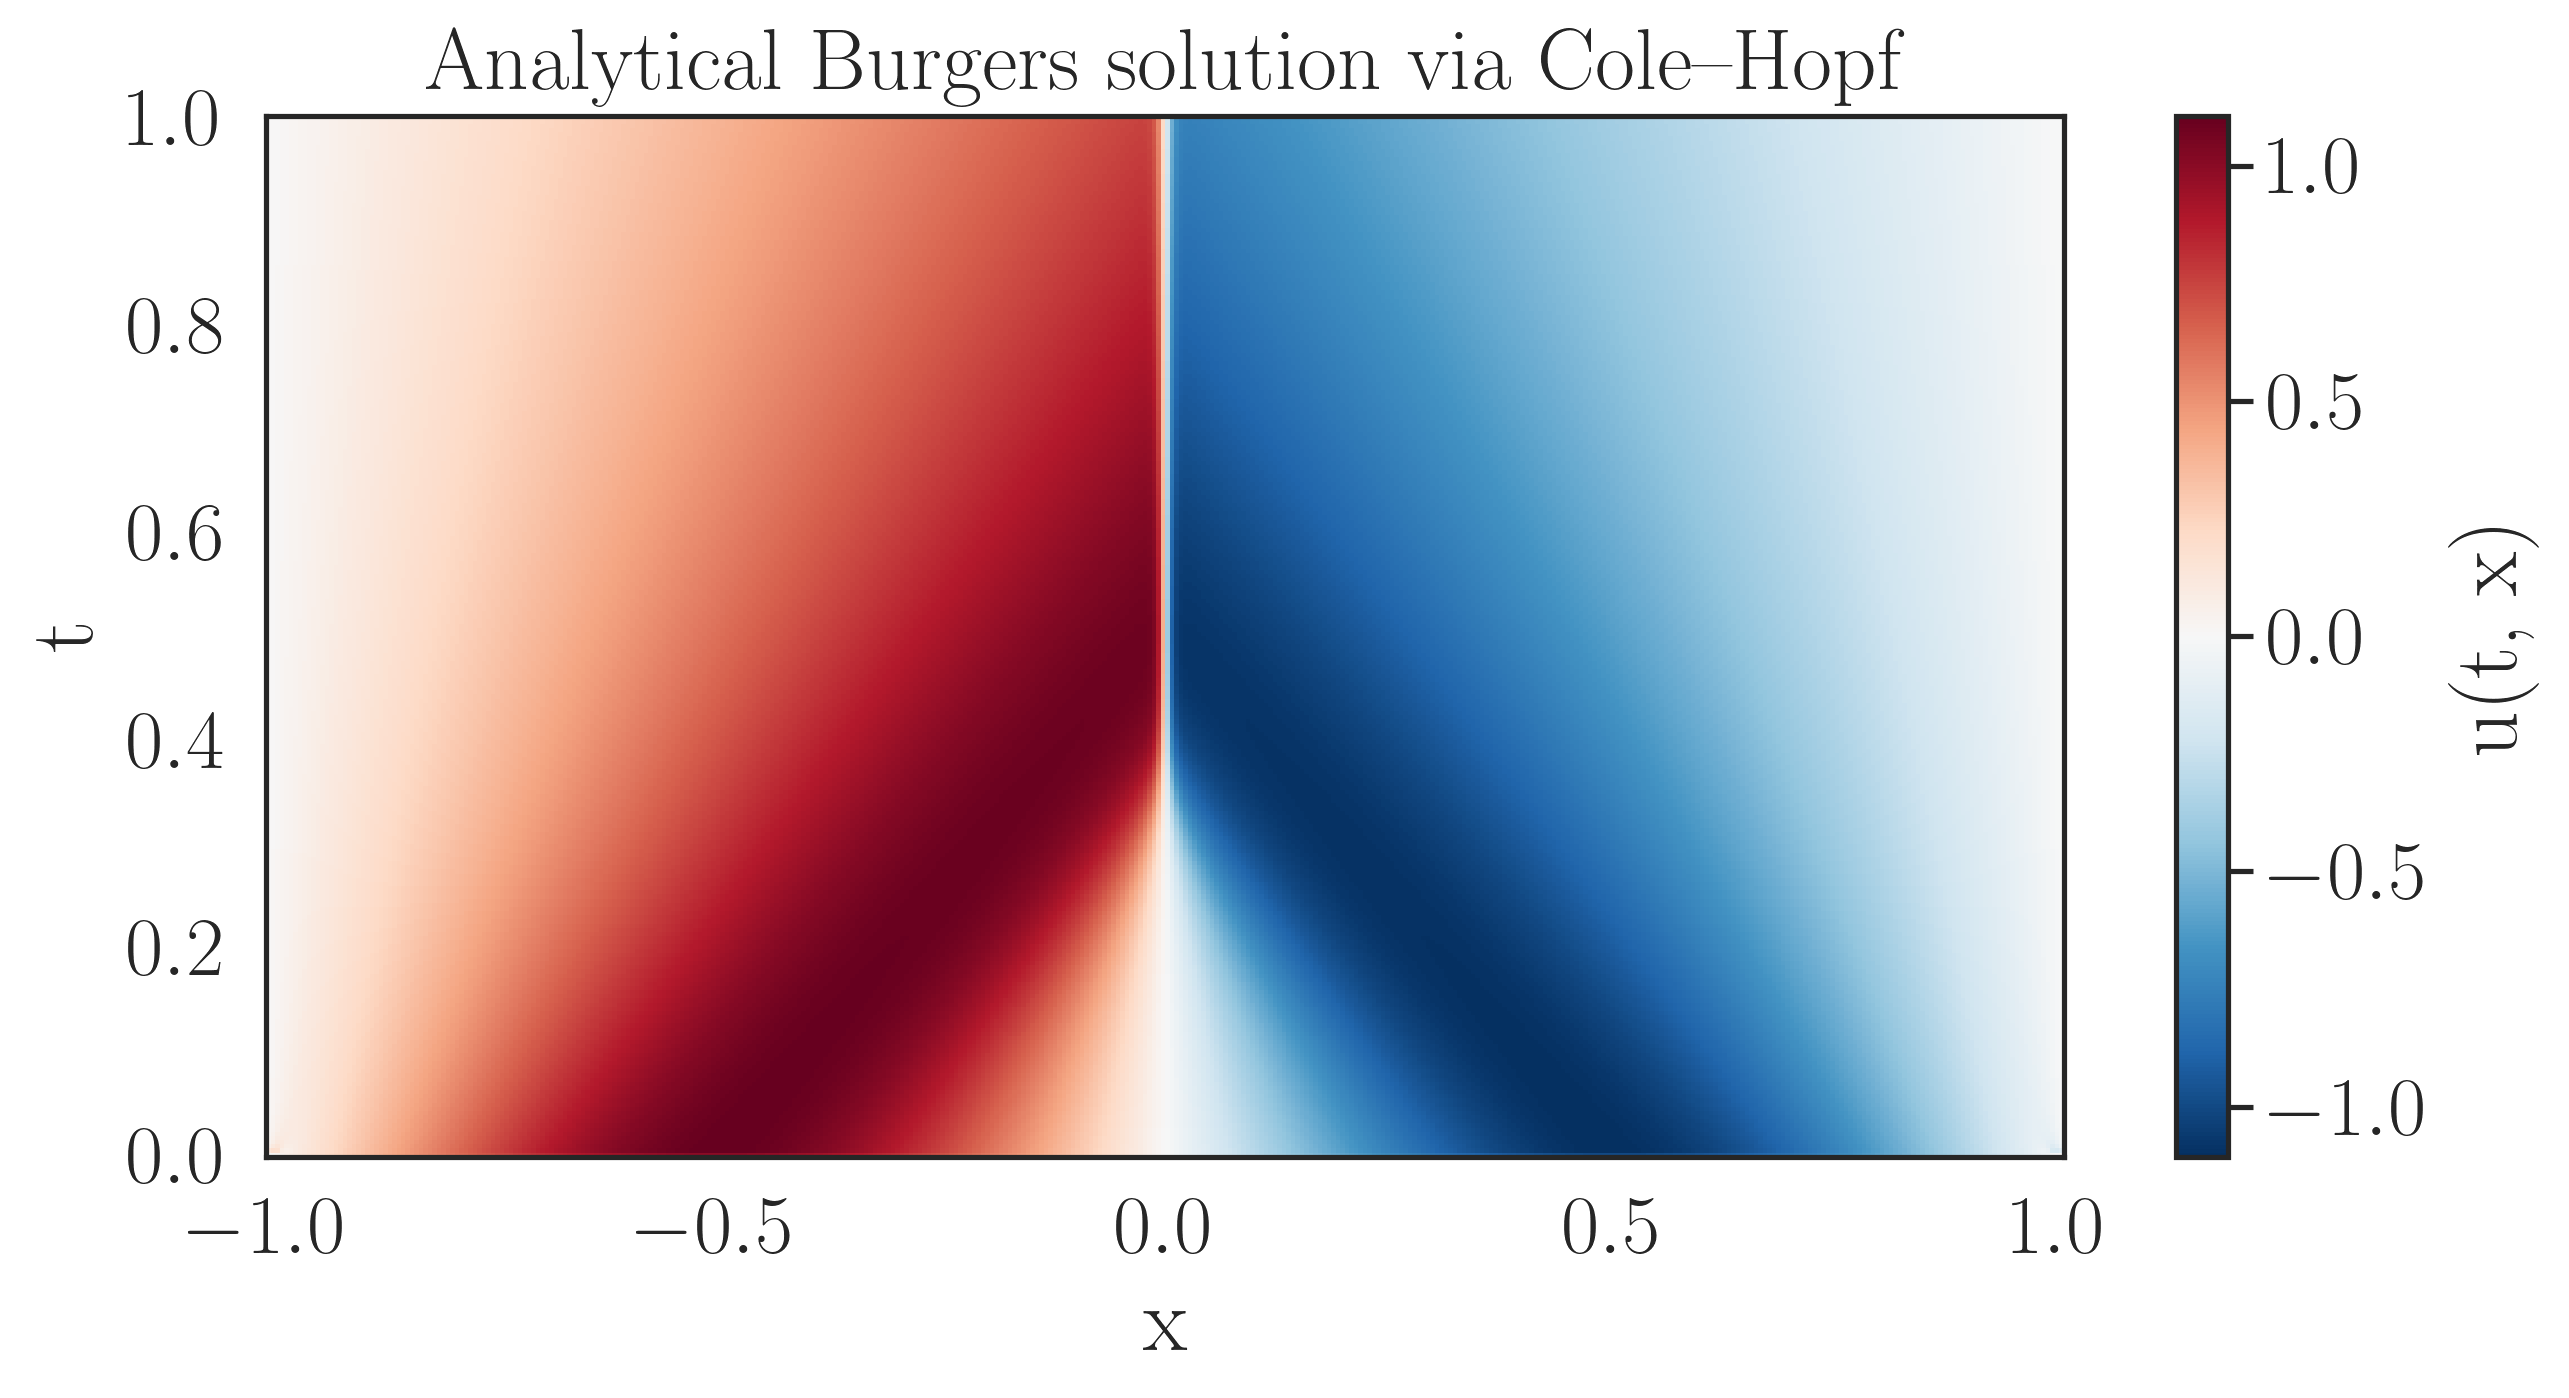

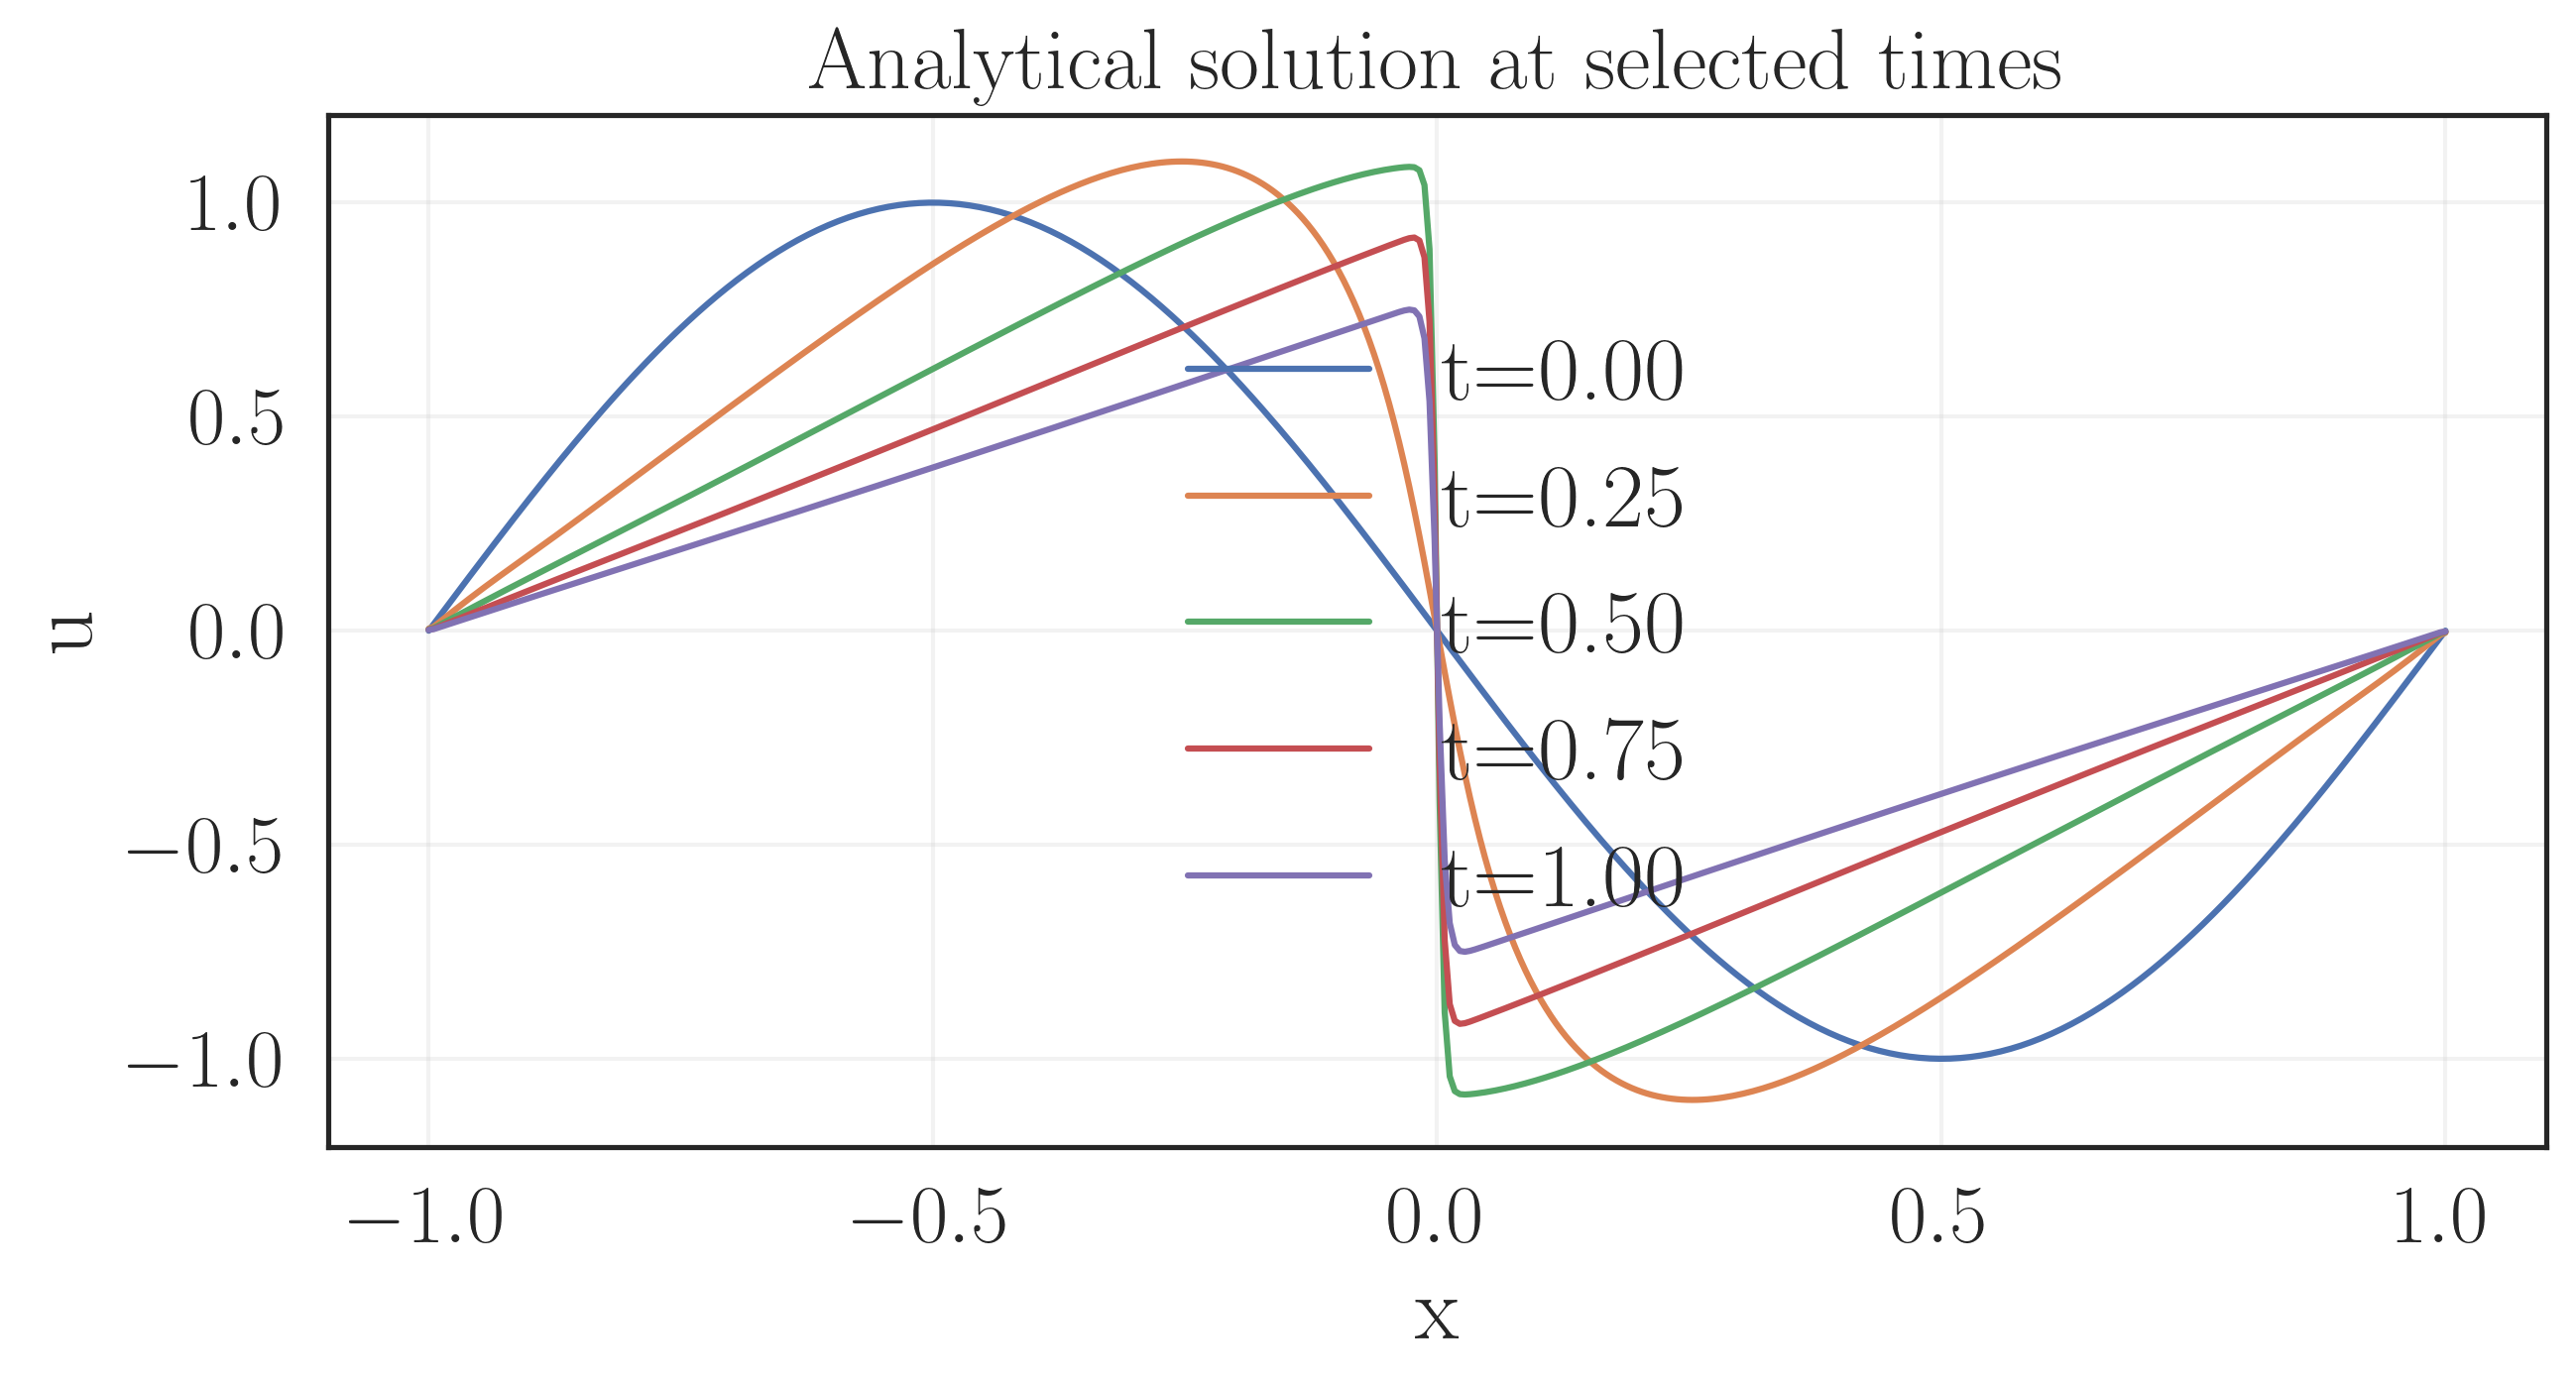

In [40]:
# import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from ground_truth.cole_hopf import cole_hopf_burgers_1d
from Plotting import heatmap_ground_truth, time_slices_ground_truth

# Parameters
L = 1.0
t_max = 1.0
nu = 0.01 / np.pi   # set your viscosity here
Nx = 400
Nt = 250

x = np.linspace(-L, L, Nx)
t = np.linspace(0, t_max, Nt)

u = cole_hopf_burgers_1d(x, t, nu, L, K=10)

# 1) Spacetime heatmap
heatmap_ground_truth(x, t, u)

# 2) Time slices
time_slices_ground_truth(x, t, Nt, u)

In [4]:
print(u.shape)

(250, 400)


### Diffusion equation

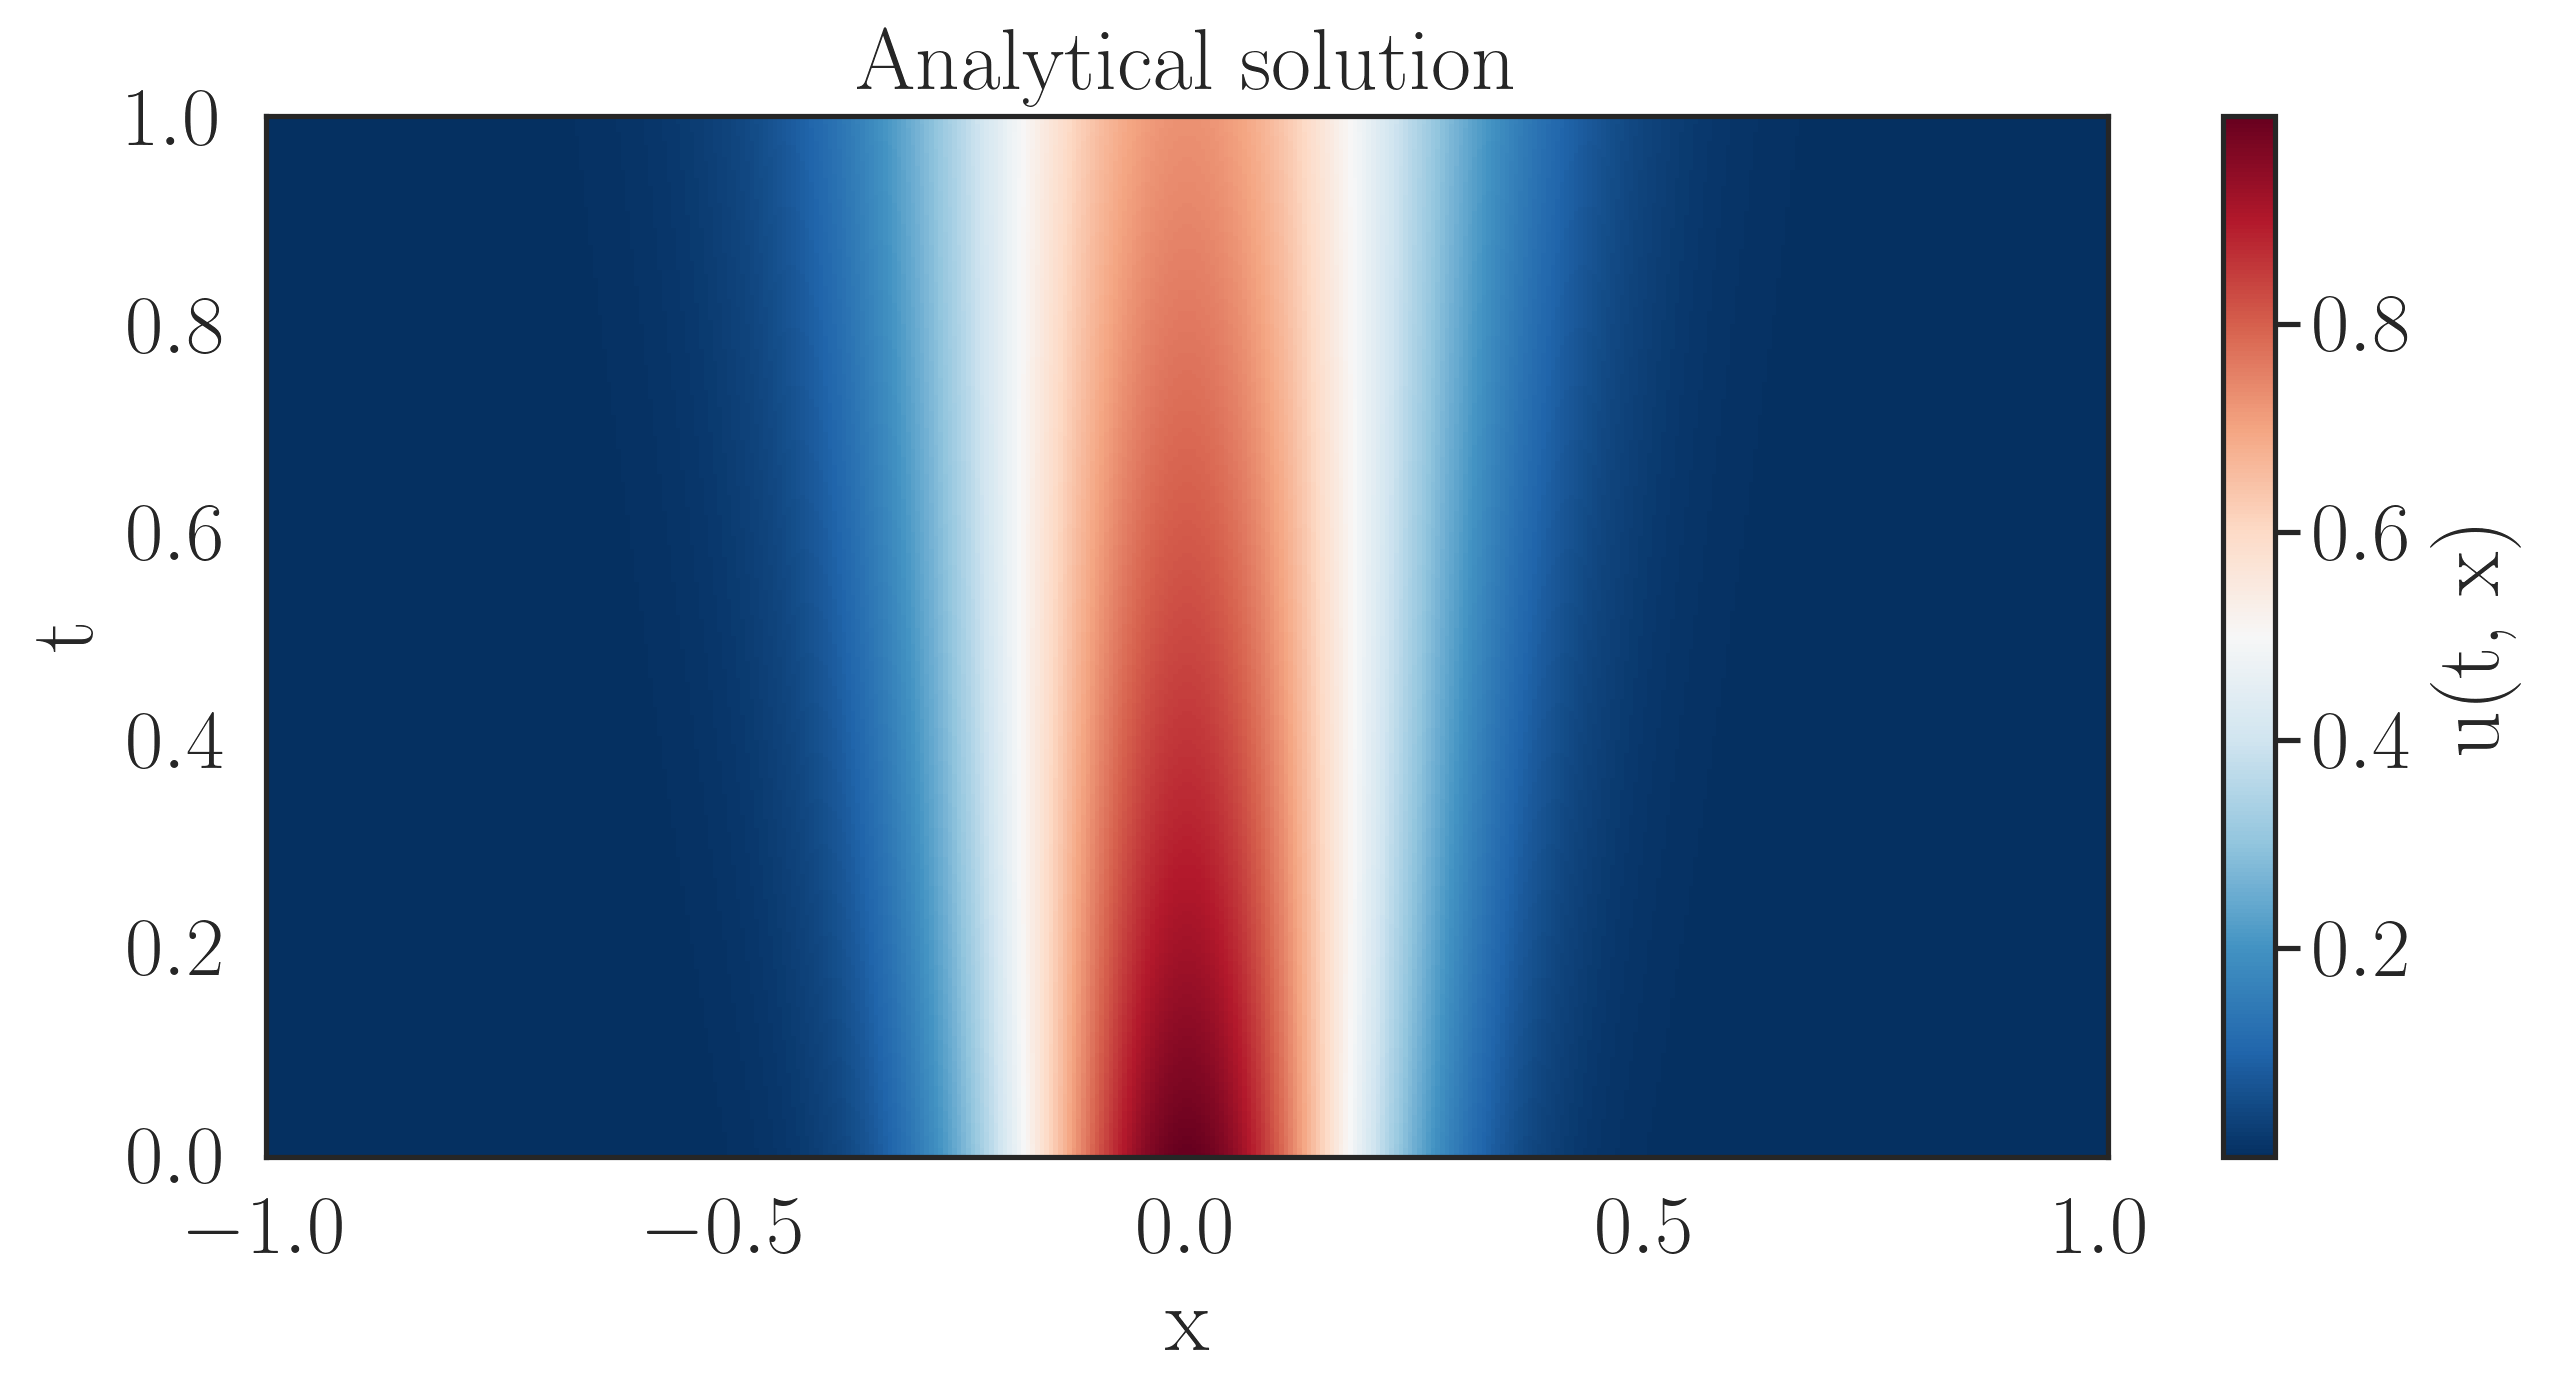

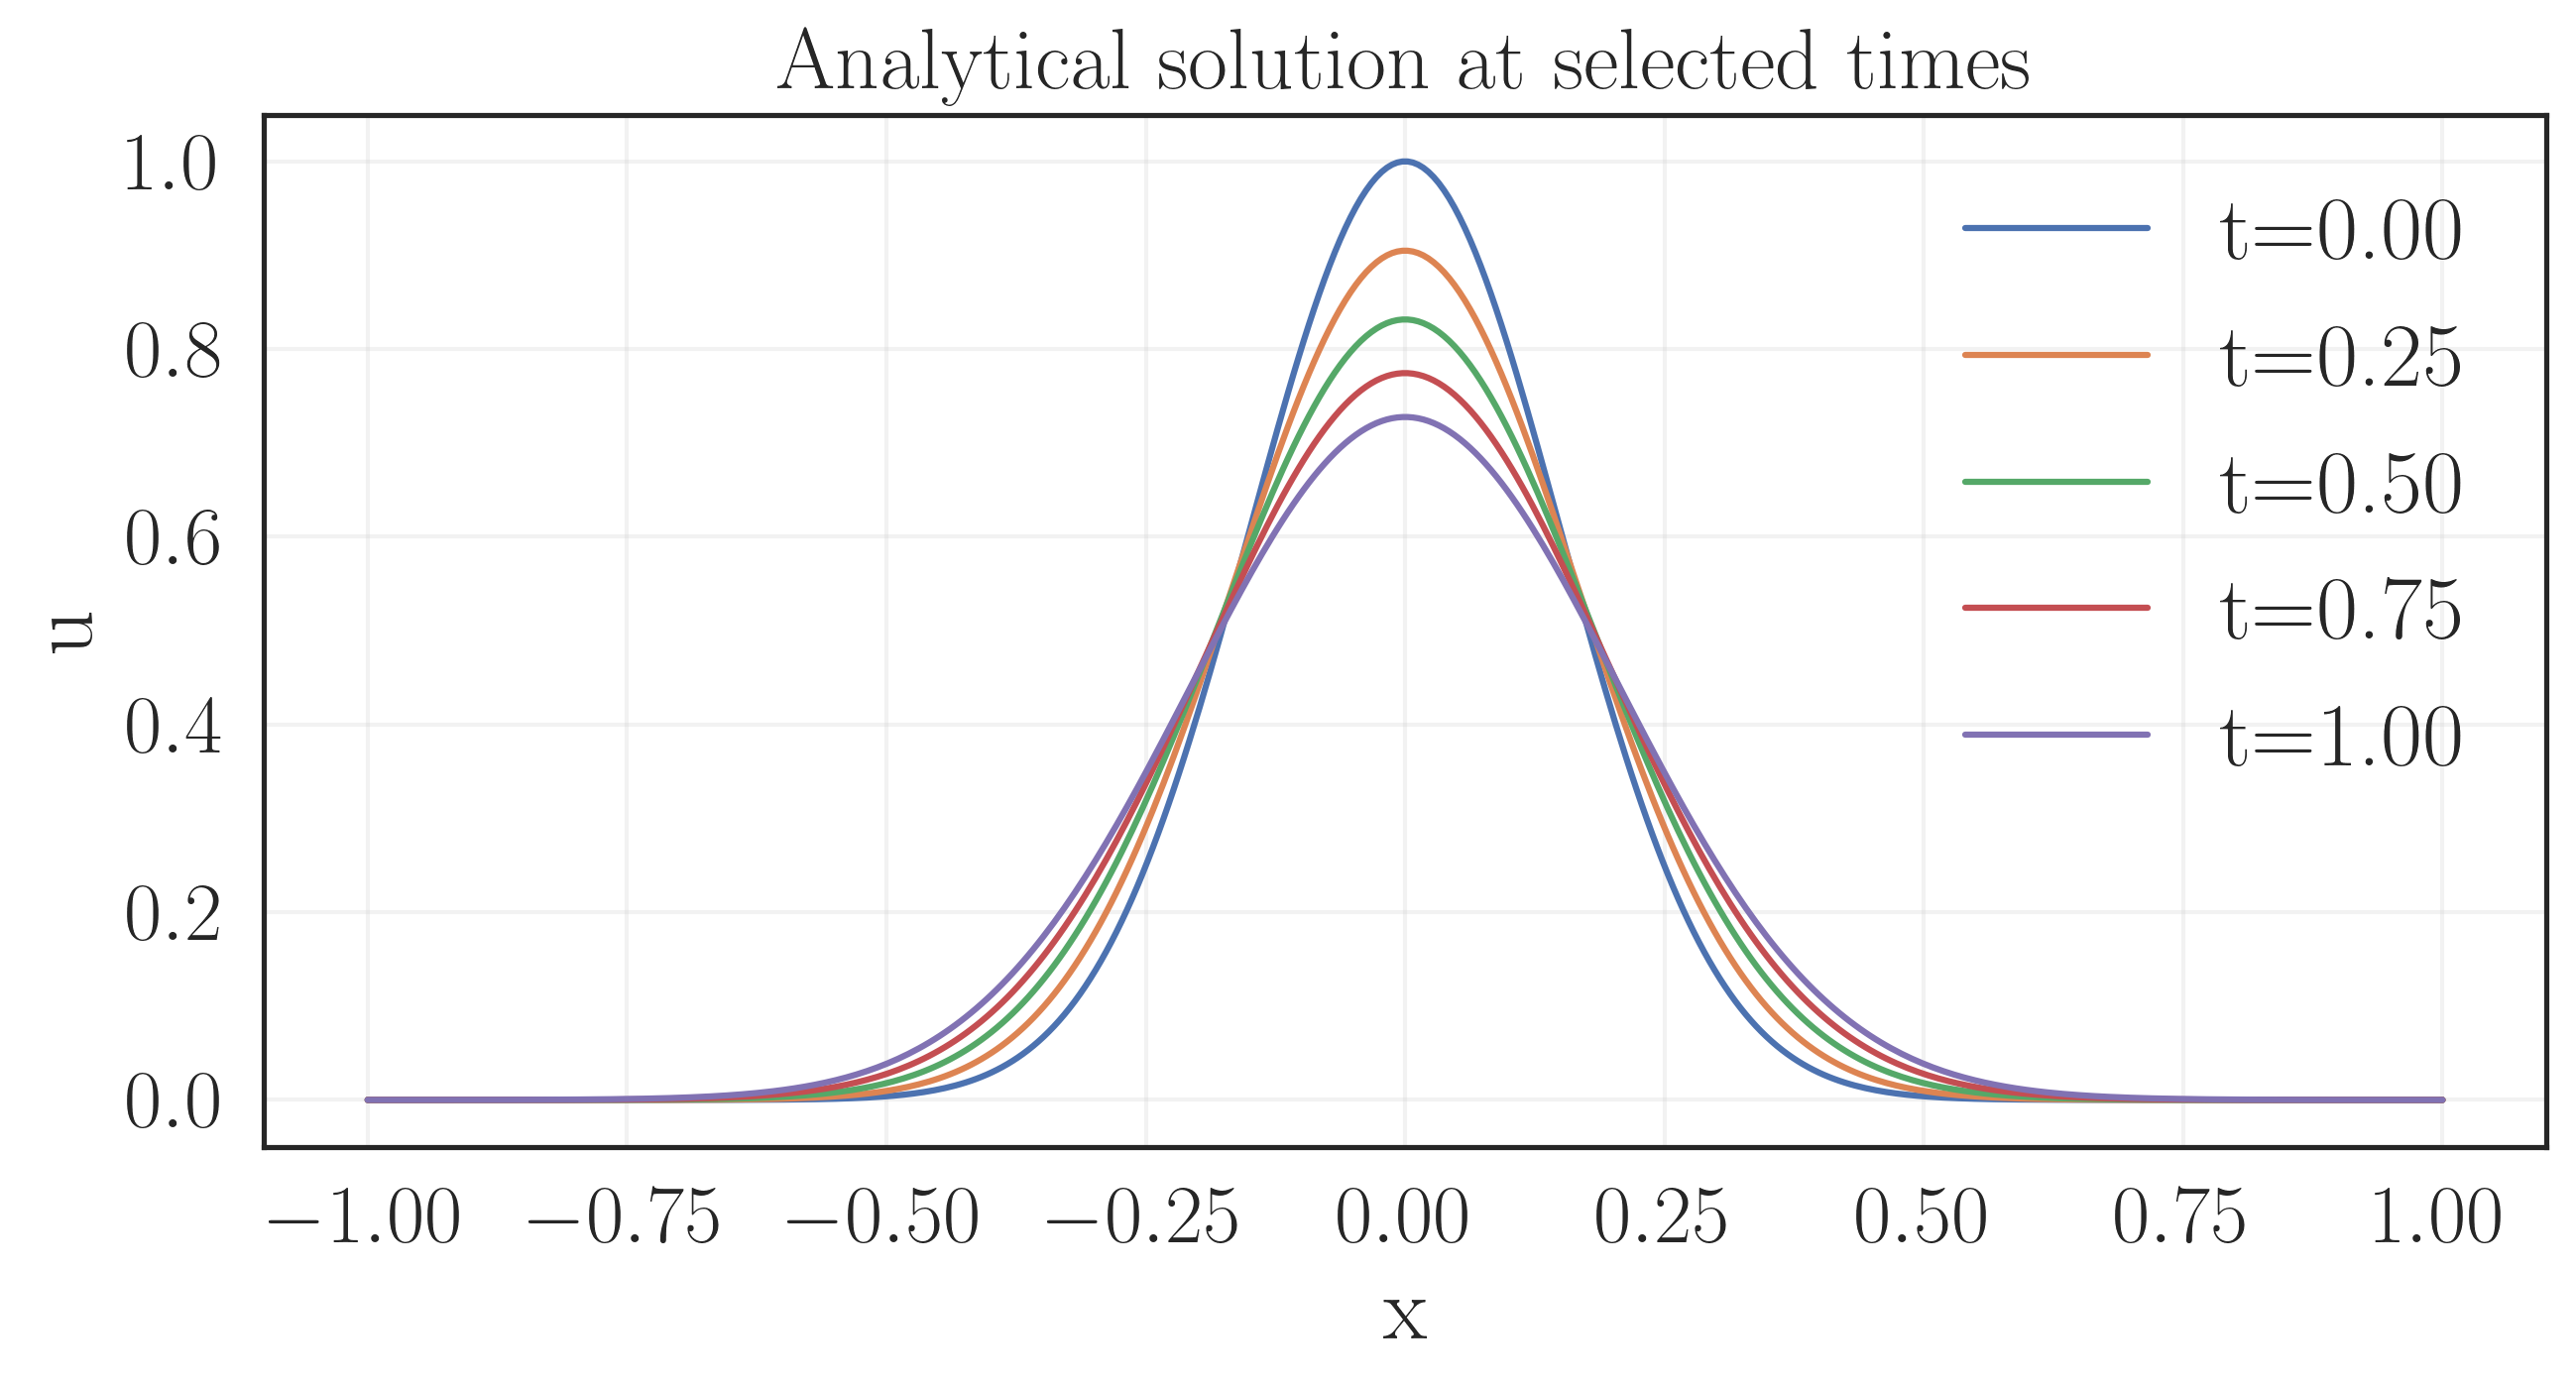

In [2]:
# plot_diffusion_gt.py
import numpy as np
import matplotlib.pyplot as plt
from ground_truth.exact_diffusion import exact_diffusion
from Plotting import heatmap_ground_truth, time_slices_ground_truth

# Parameters
L = 1.0
t_max = 1.0
c = 0.01          # diffusion coefficient (matches PINN's D=0.01)
K = 20            # number of image pairs for periodic wrapping

Nx = 400
Nt = 250

x = np.linspace(-L, L, Nx)
t = np.linspace(0, t_max, Nt)

# Compute exact solution
u = exact_diffusion(x, t, c=c, L=L, K=K)

# 1) Spacetime heatmap
heatmap_ground_truth(x, t, u)

# 2) Time slices at selected times
time_slices_ground_truth(x, t, u)

### Wave equation

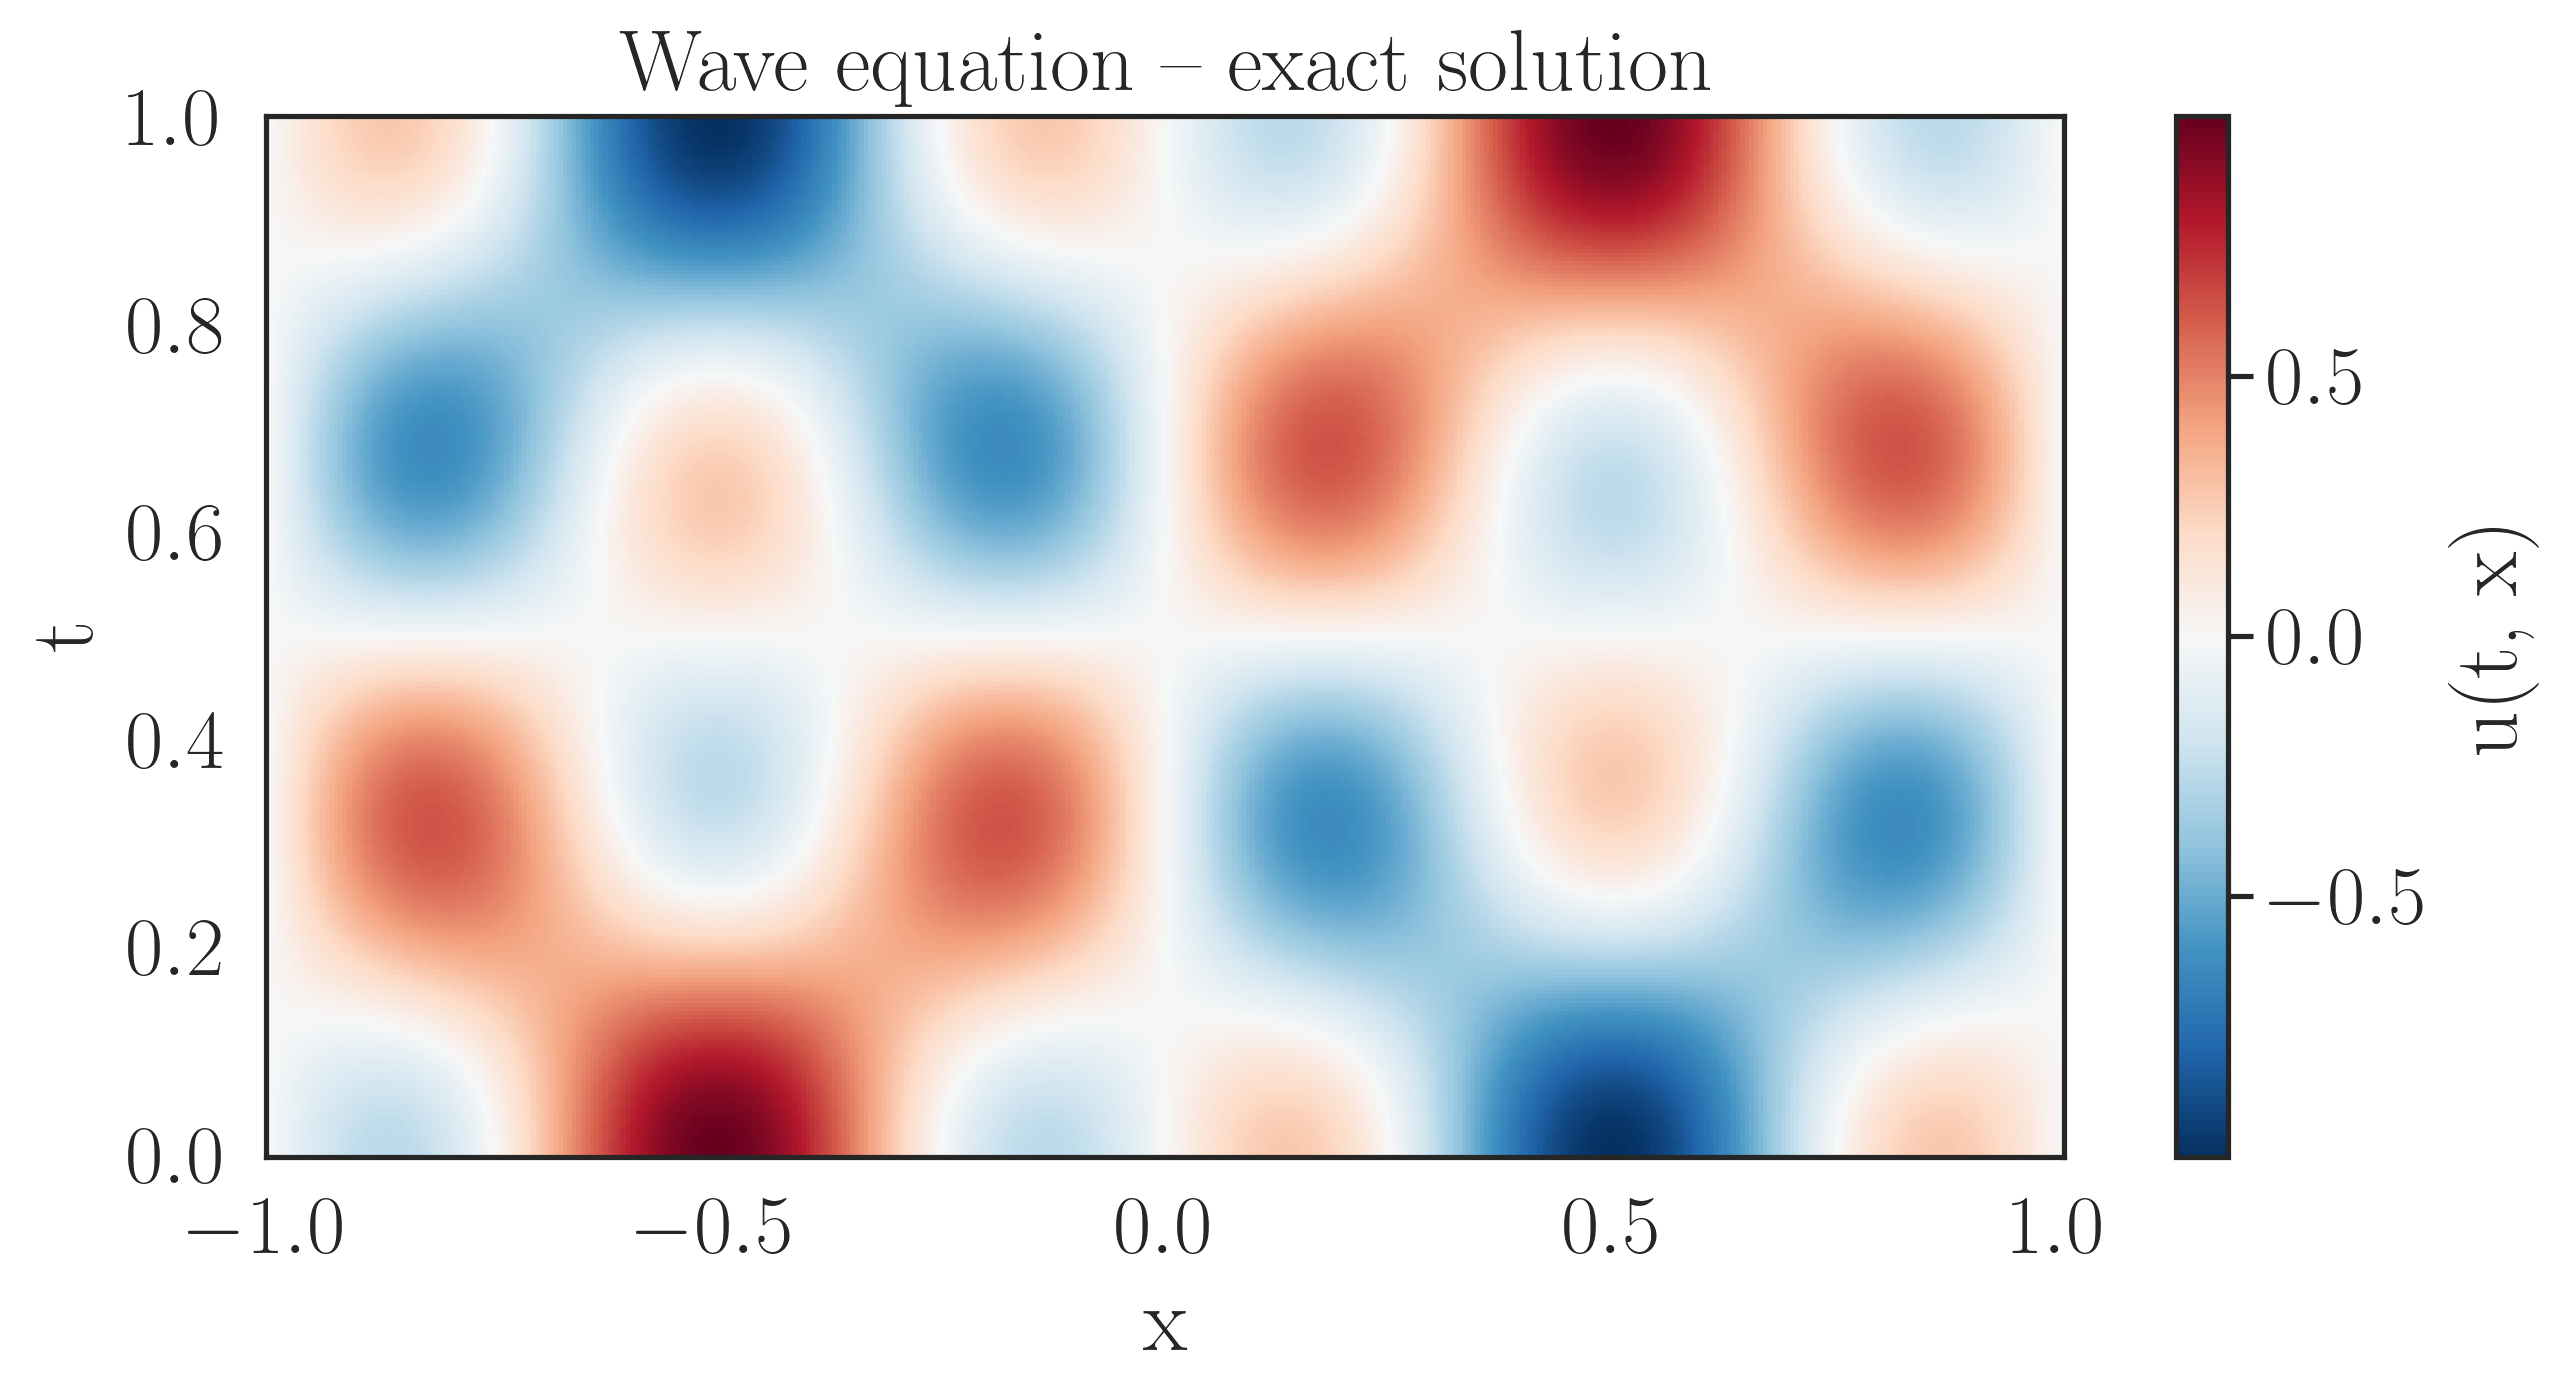

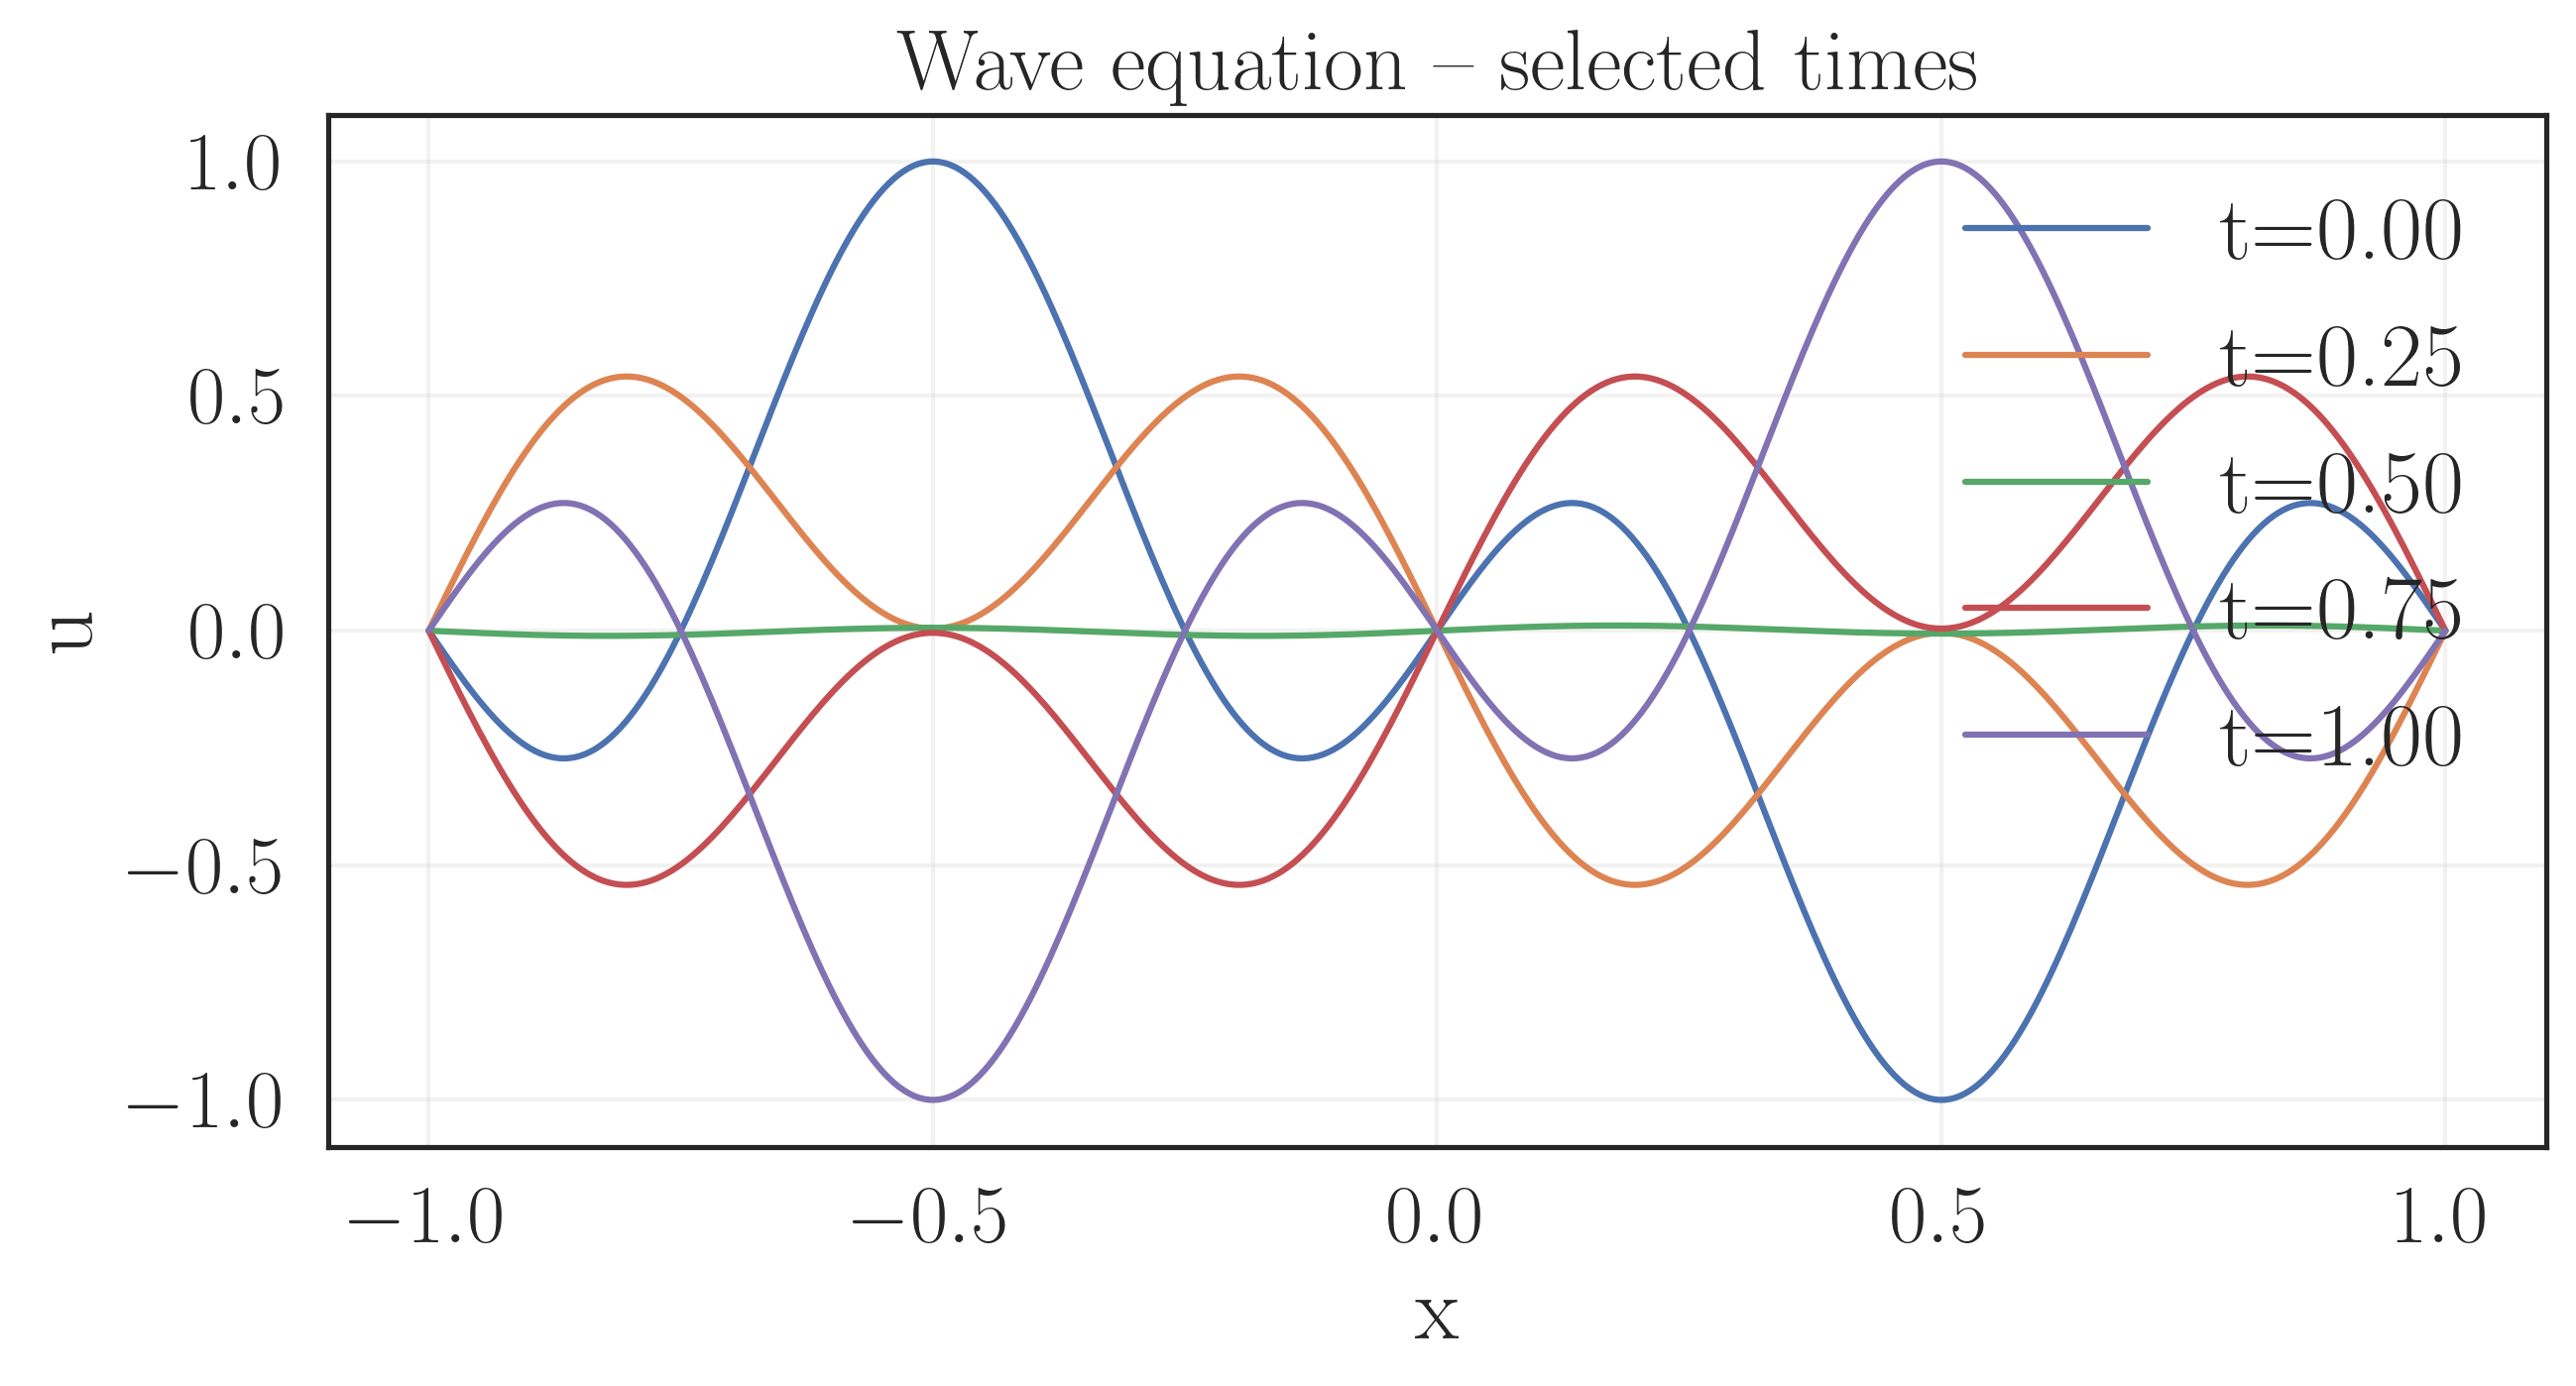

In [3]:
# plot_wave_gt.py
import numpy as np
from ground_truth.exact_wave import exact_wave
from Plotting import heatmap_ground_truth, time_slices_ground_truth

# Parameters
L = 1.0          # half‑domain length
c = 1.0          # wave speed
t_max = 1.0      # final time

Nx = 400         # spatial resolution
Nt = 250         # temporal resolution

x = np.linspace(-L, L, Nx)
t = np.linspace(0, t_max, Nt)

# Compute exact solution
u = exact_wave(x, t, L=L, c=c)

# 1) Spacetime heatmap
heatmap_ground_truth(x, t, u, title="Wave equation – exact solution")

# 2) Time slices at selected times
time_slices_ground_truth(x, t, u, title="Wave equation – selected times")

### Euler/Sod

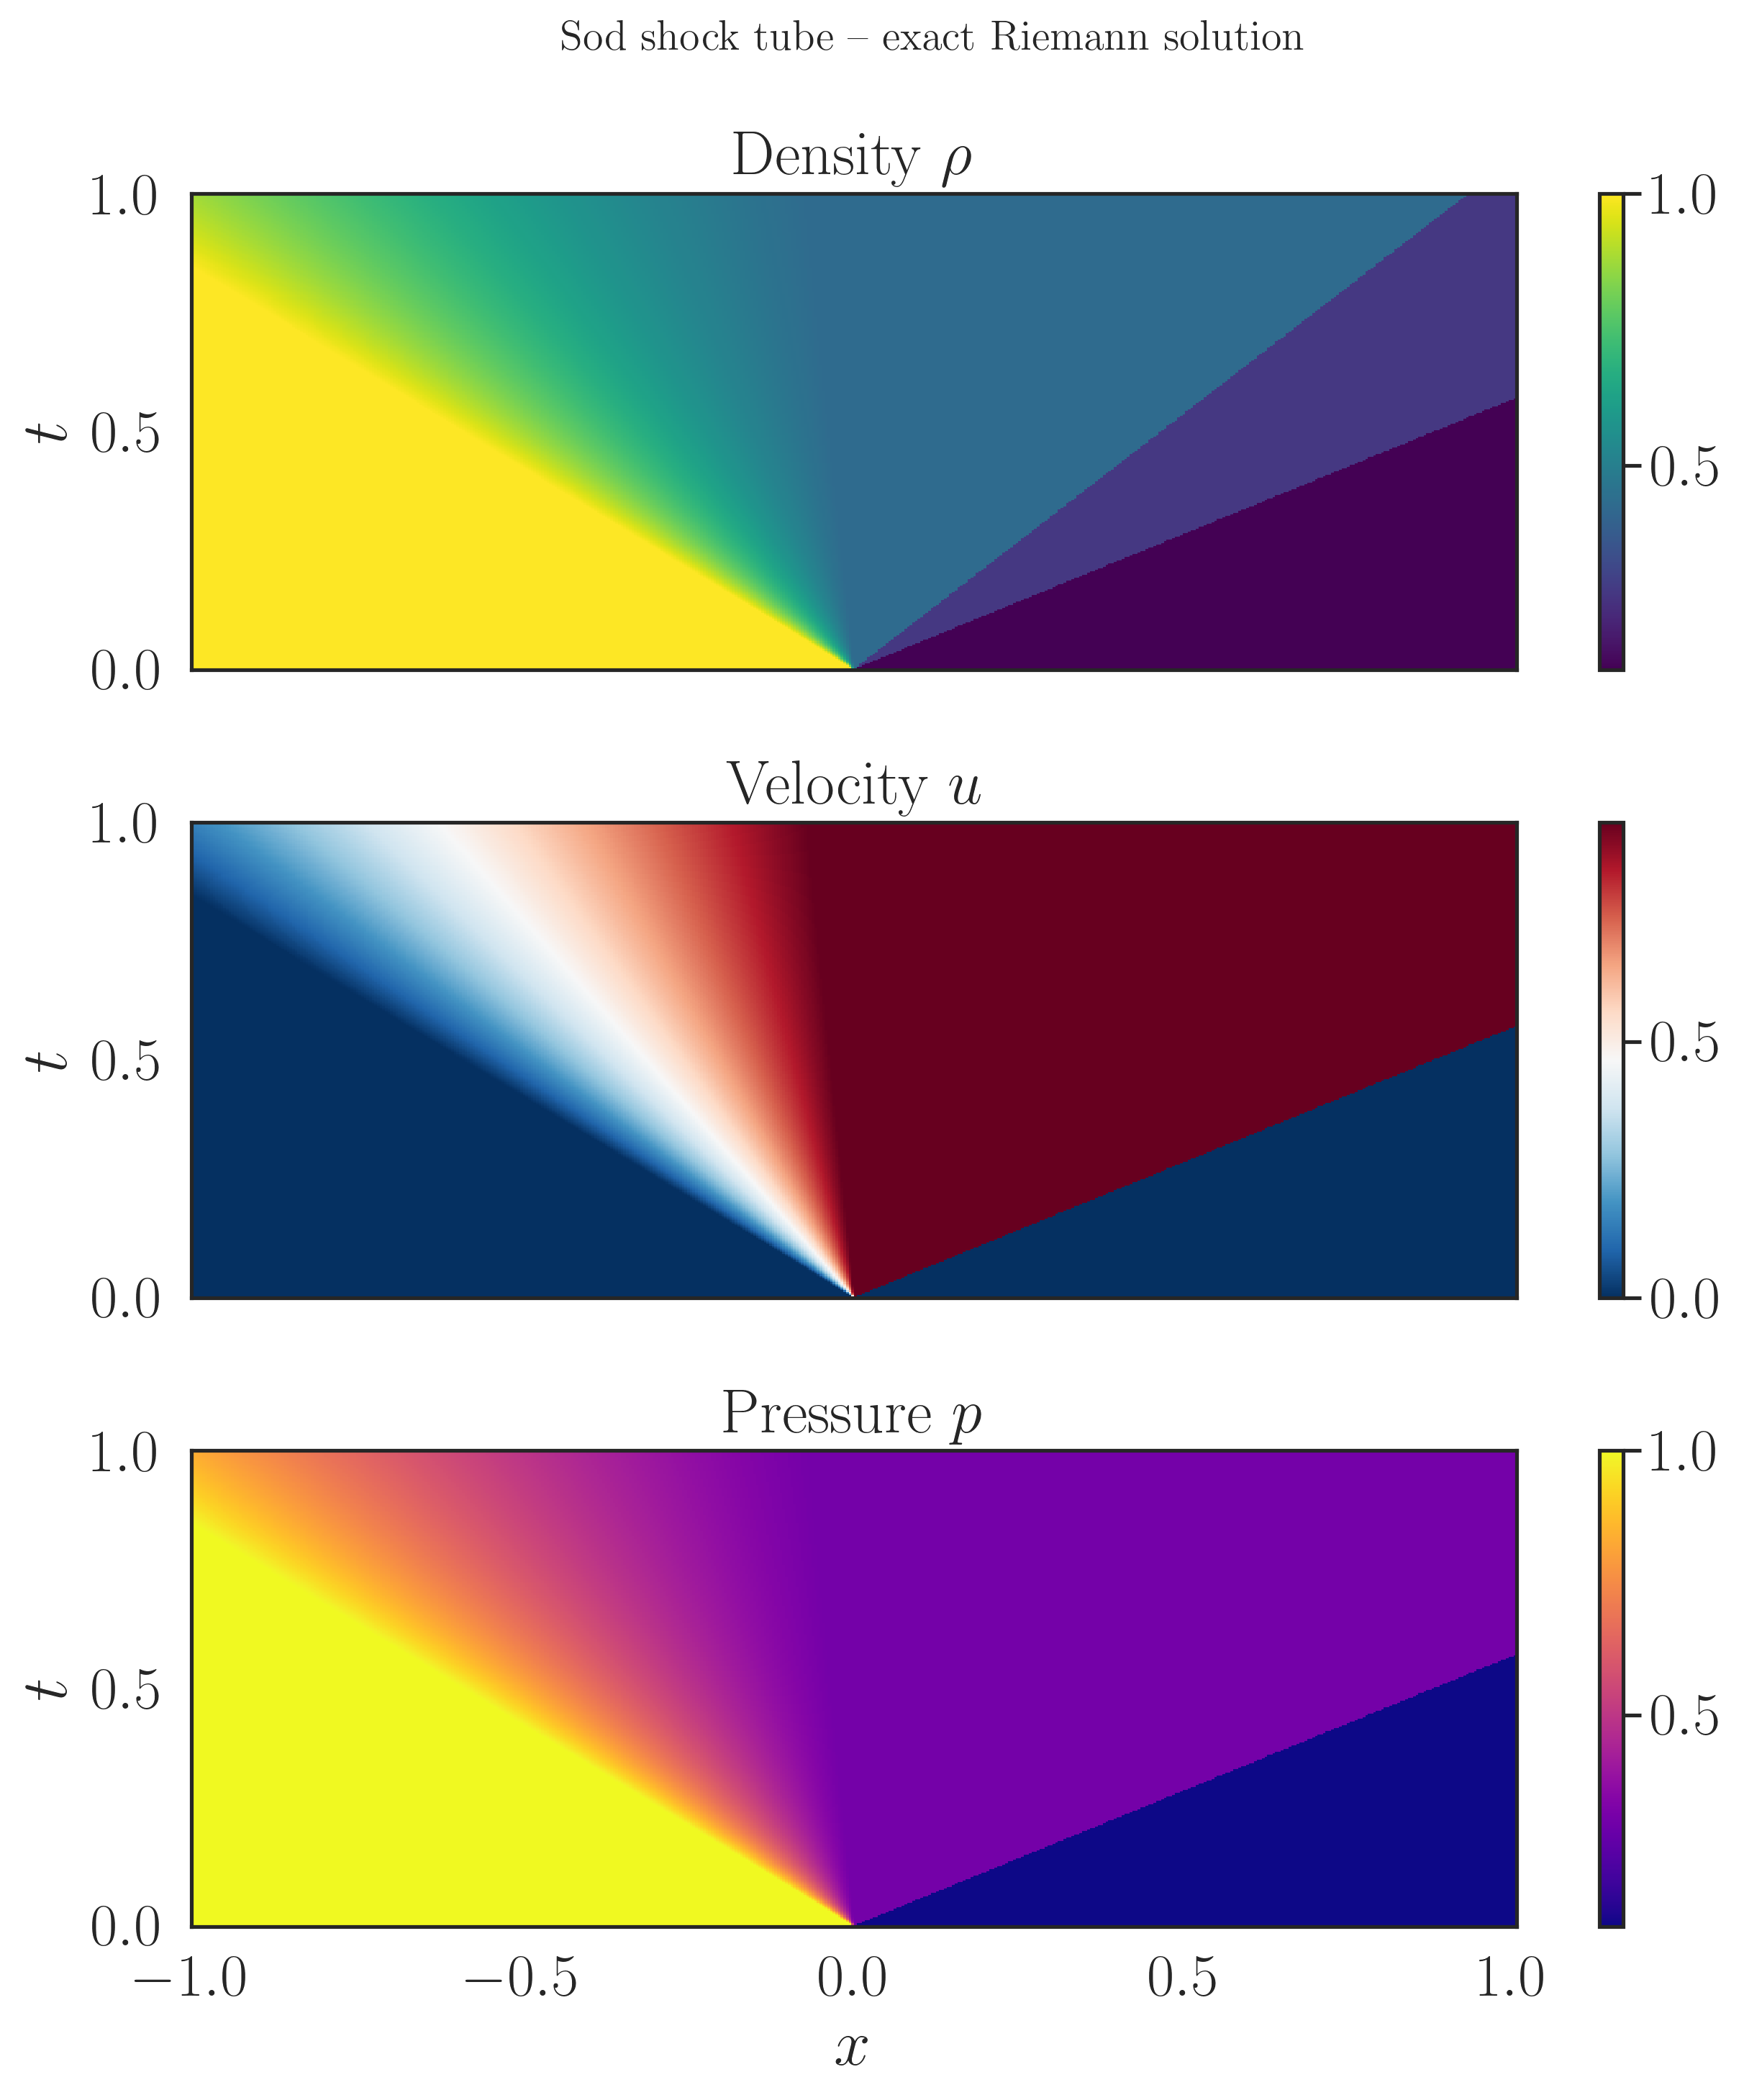

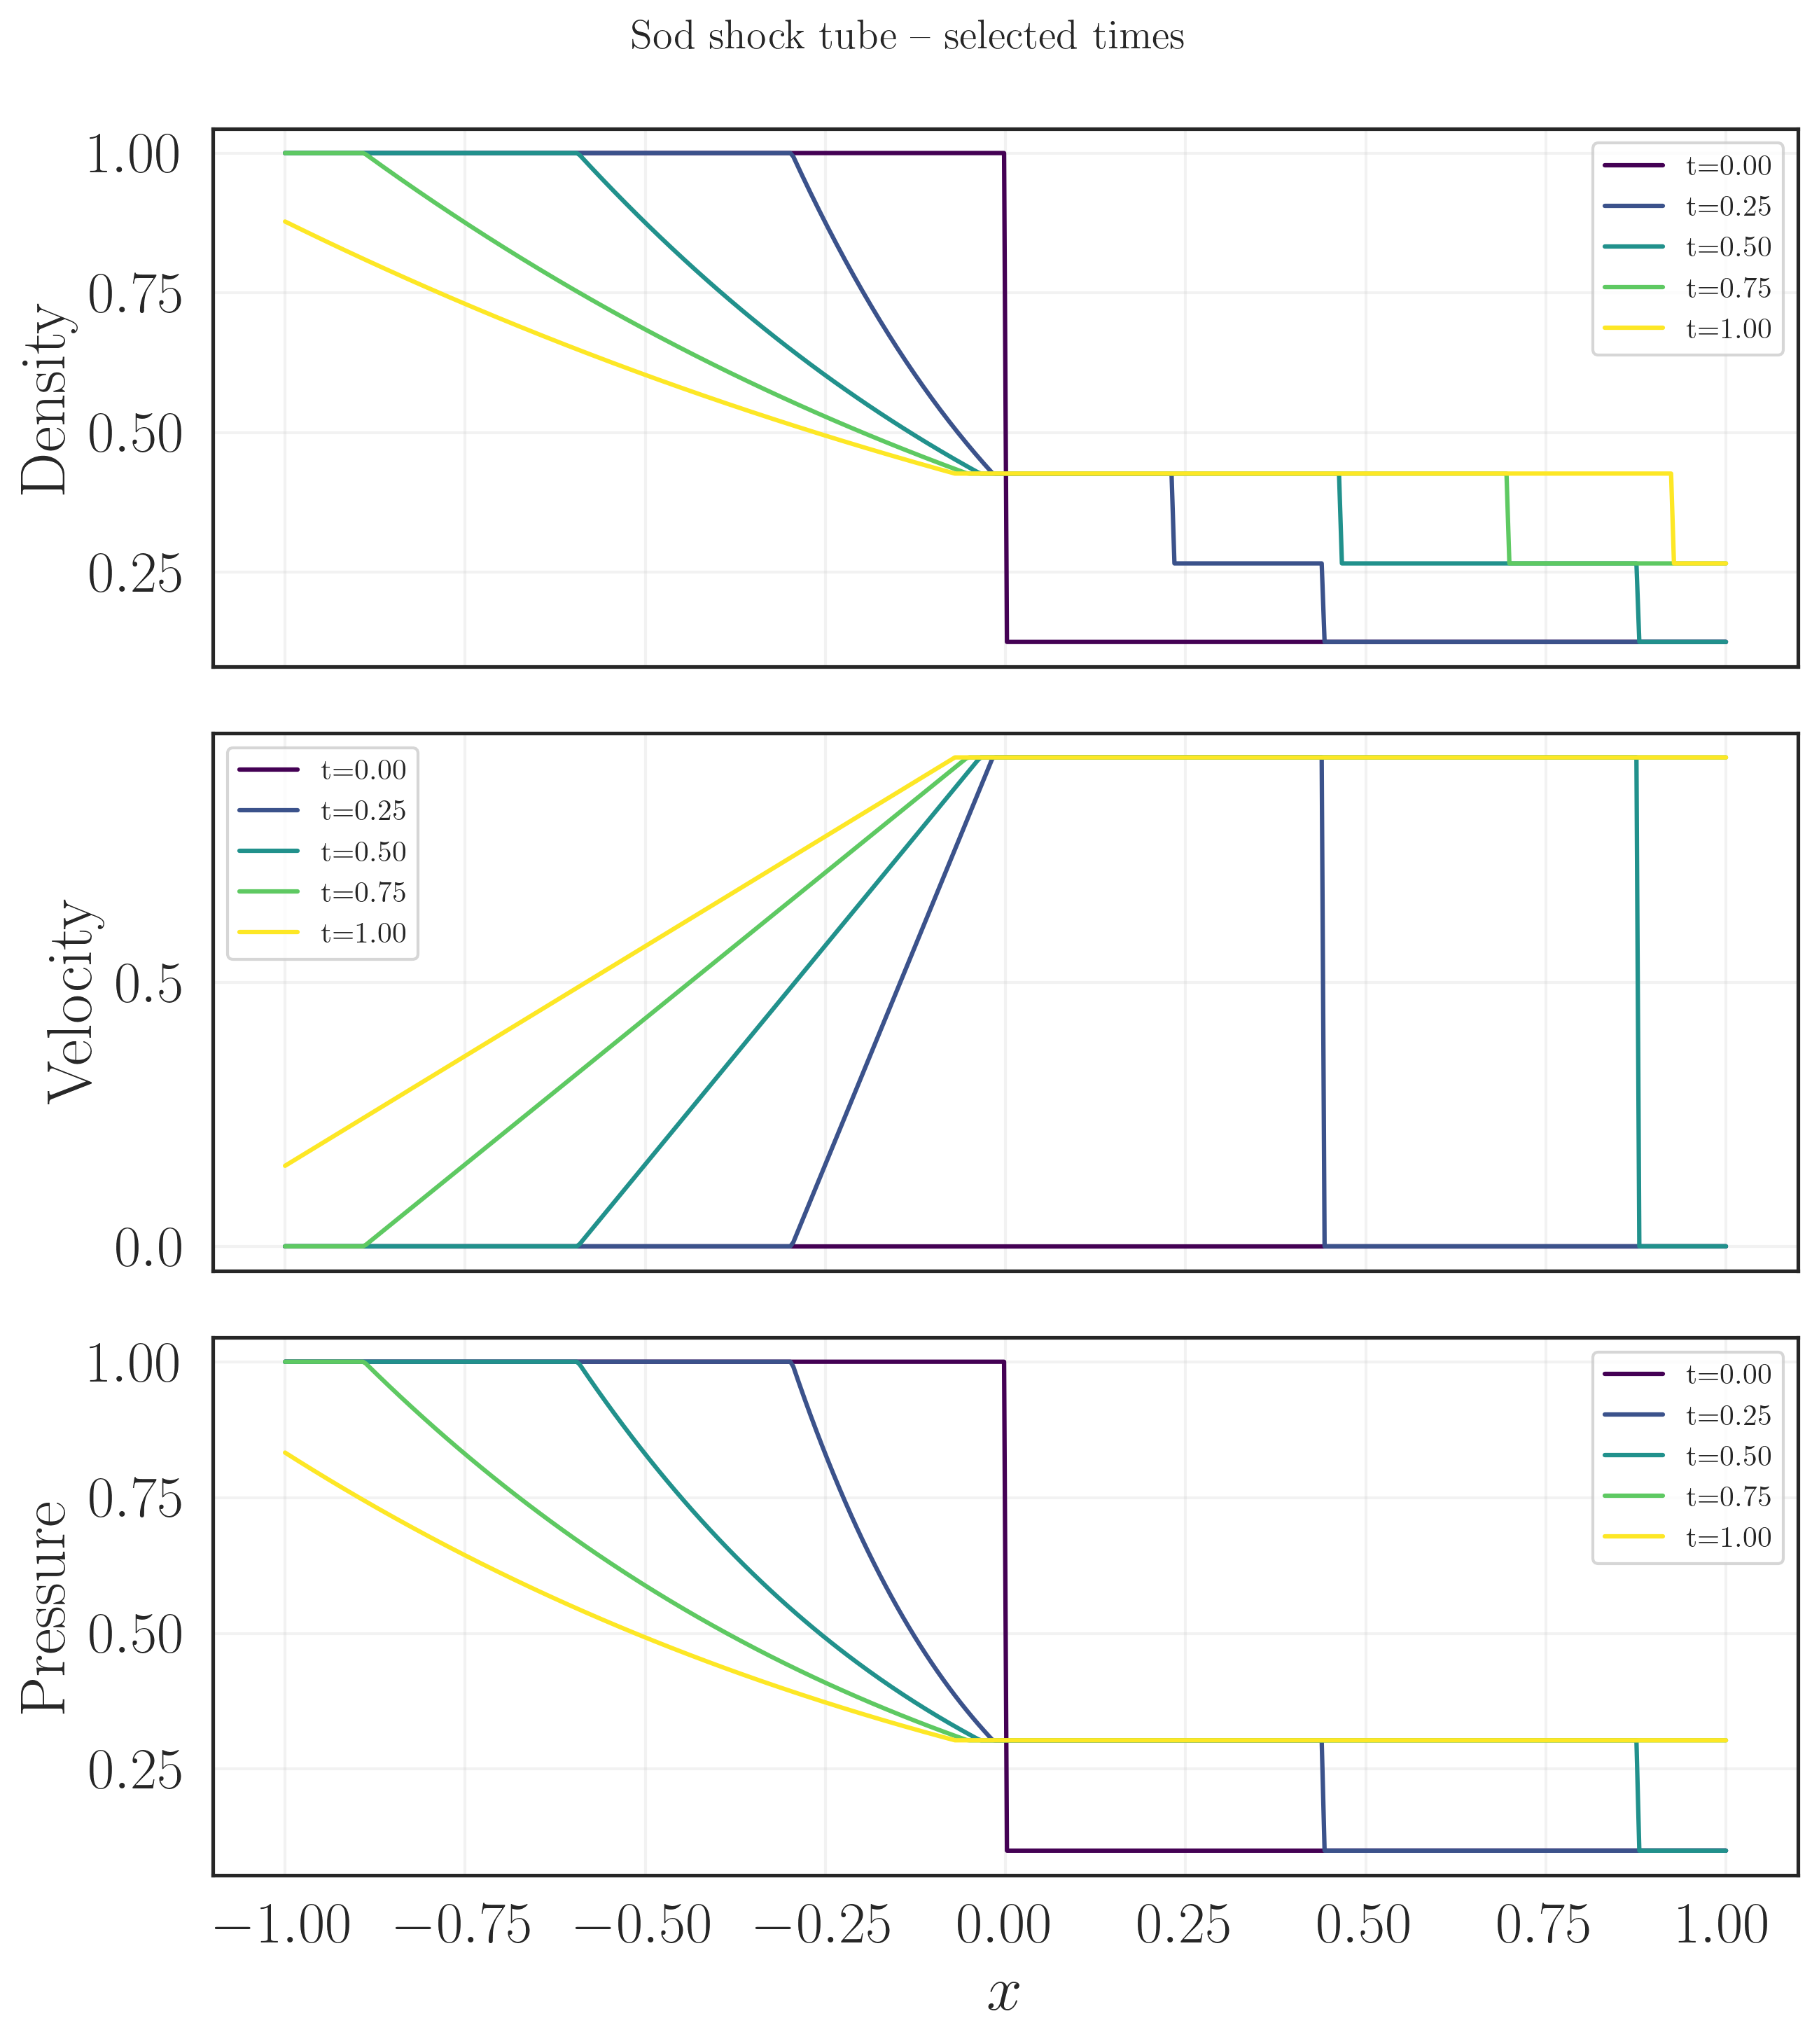

In [4]:
# plot_sod_gt.py
import numpy as np
from ground_truth.exact_sod import exact_sod
from Plotting import heatmap_sod_ground_truth, time_slices_sod_ground_truth

# Parameters
L = 1.0          # domain [-L, L]
t_max = 1.0      # final time
Nx = 500         # spatial resolution
Nt = 300         # temporal resolution

x = np.linspace(-L, L, Nx)
t = np.linspace(0, t_max, Nt)

# Compute exact solution (returns dictionary)
sol = exact_sod(x, t, rho_L=1.0, v_L=0.0, p_L=1.0,
                rho_R=0.125, v_R=0.0, p_R=0.1, x0=0.0)

rho_gt = sol['rho']   # shape (Nt, Nx)
v_gt   = sol['v']
p_gt   = sol['p']

# 1) Heatmaps for density, velocity, pressure
heatmap_sod_ground_truth(x, t, rho_gt, v_gt, p_gt, title="Sod shock tube – exact Riemann solution")

# 2) Time slices at selected times
time_slices_sod_ground_truth(x, t, rho_gt, v_gt, p_gt)

### $L^2$ relative error 

/home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/ground_truth/cole_hopf.py:49: RuntimeWarning: invalid value encountered in divide
  u[ti, :] = -2 * nu * dphi_dx / phi
/home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/ground_truth/cole_hopf.py:49: RuntimeWarning: divide by zero encountered in divide
  u[ti, :] = -2 * nu * dphi_dx / phi


Relative L2(u)  over spacetime = 2.645610e-01
[saved] /home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/results/L2_results.txt


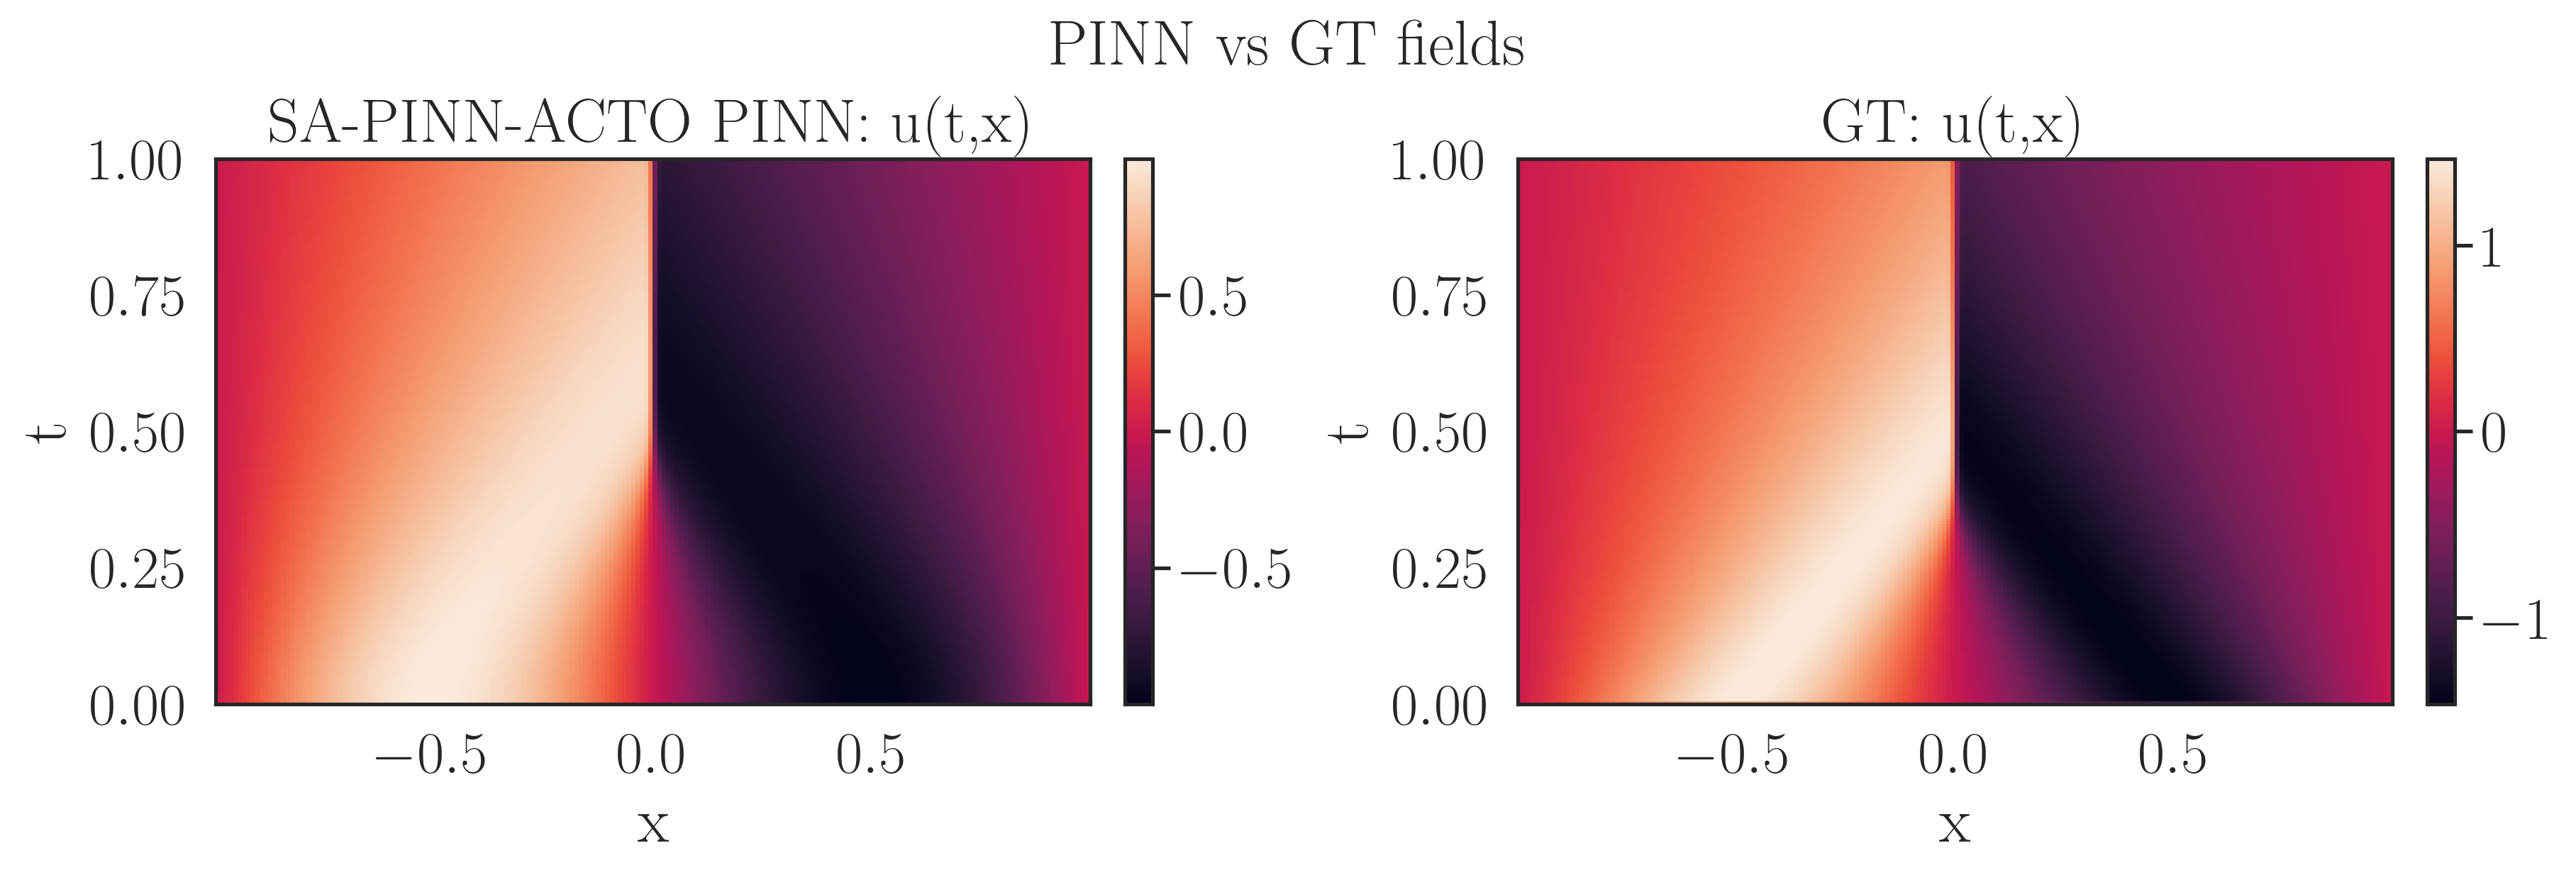

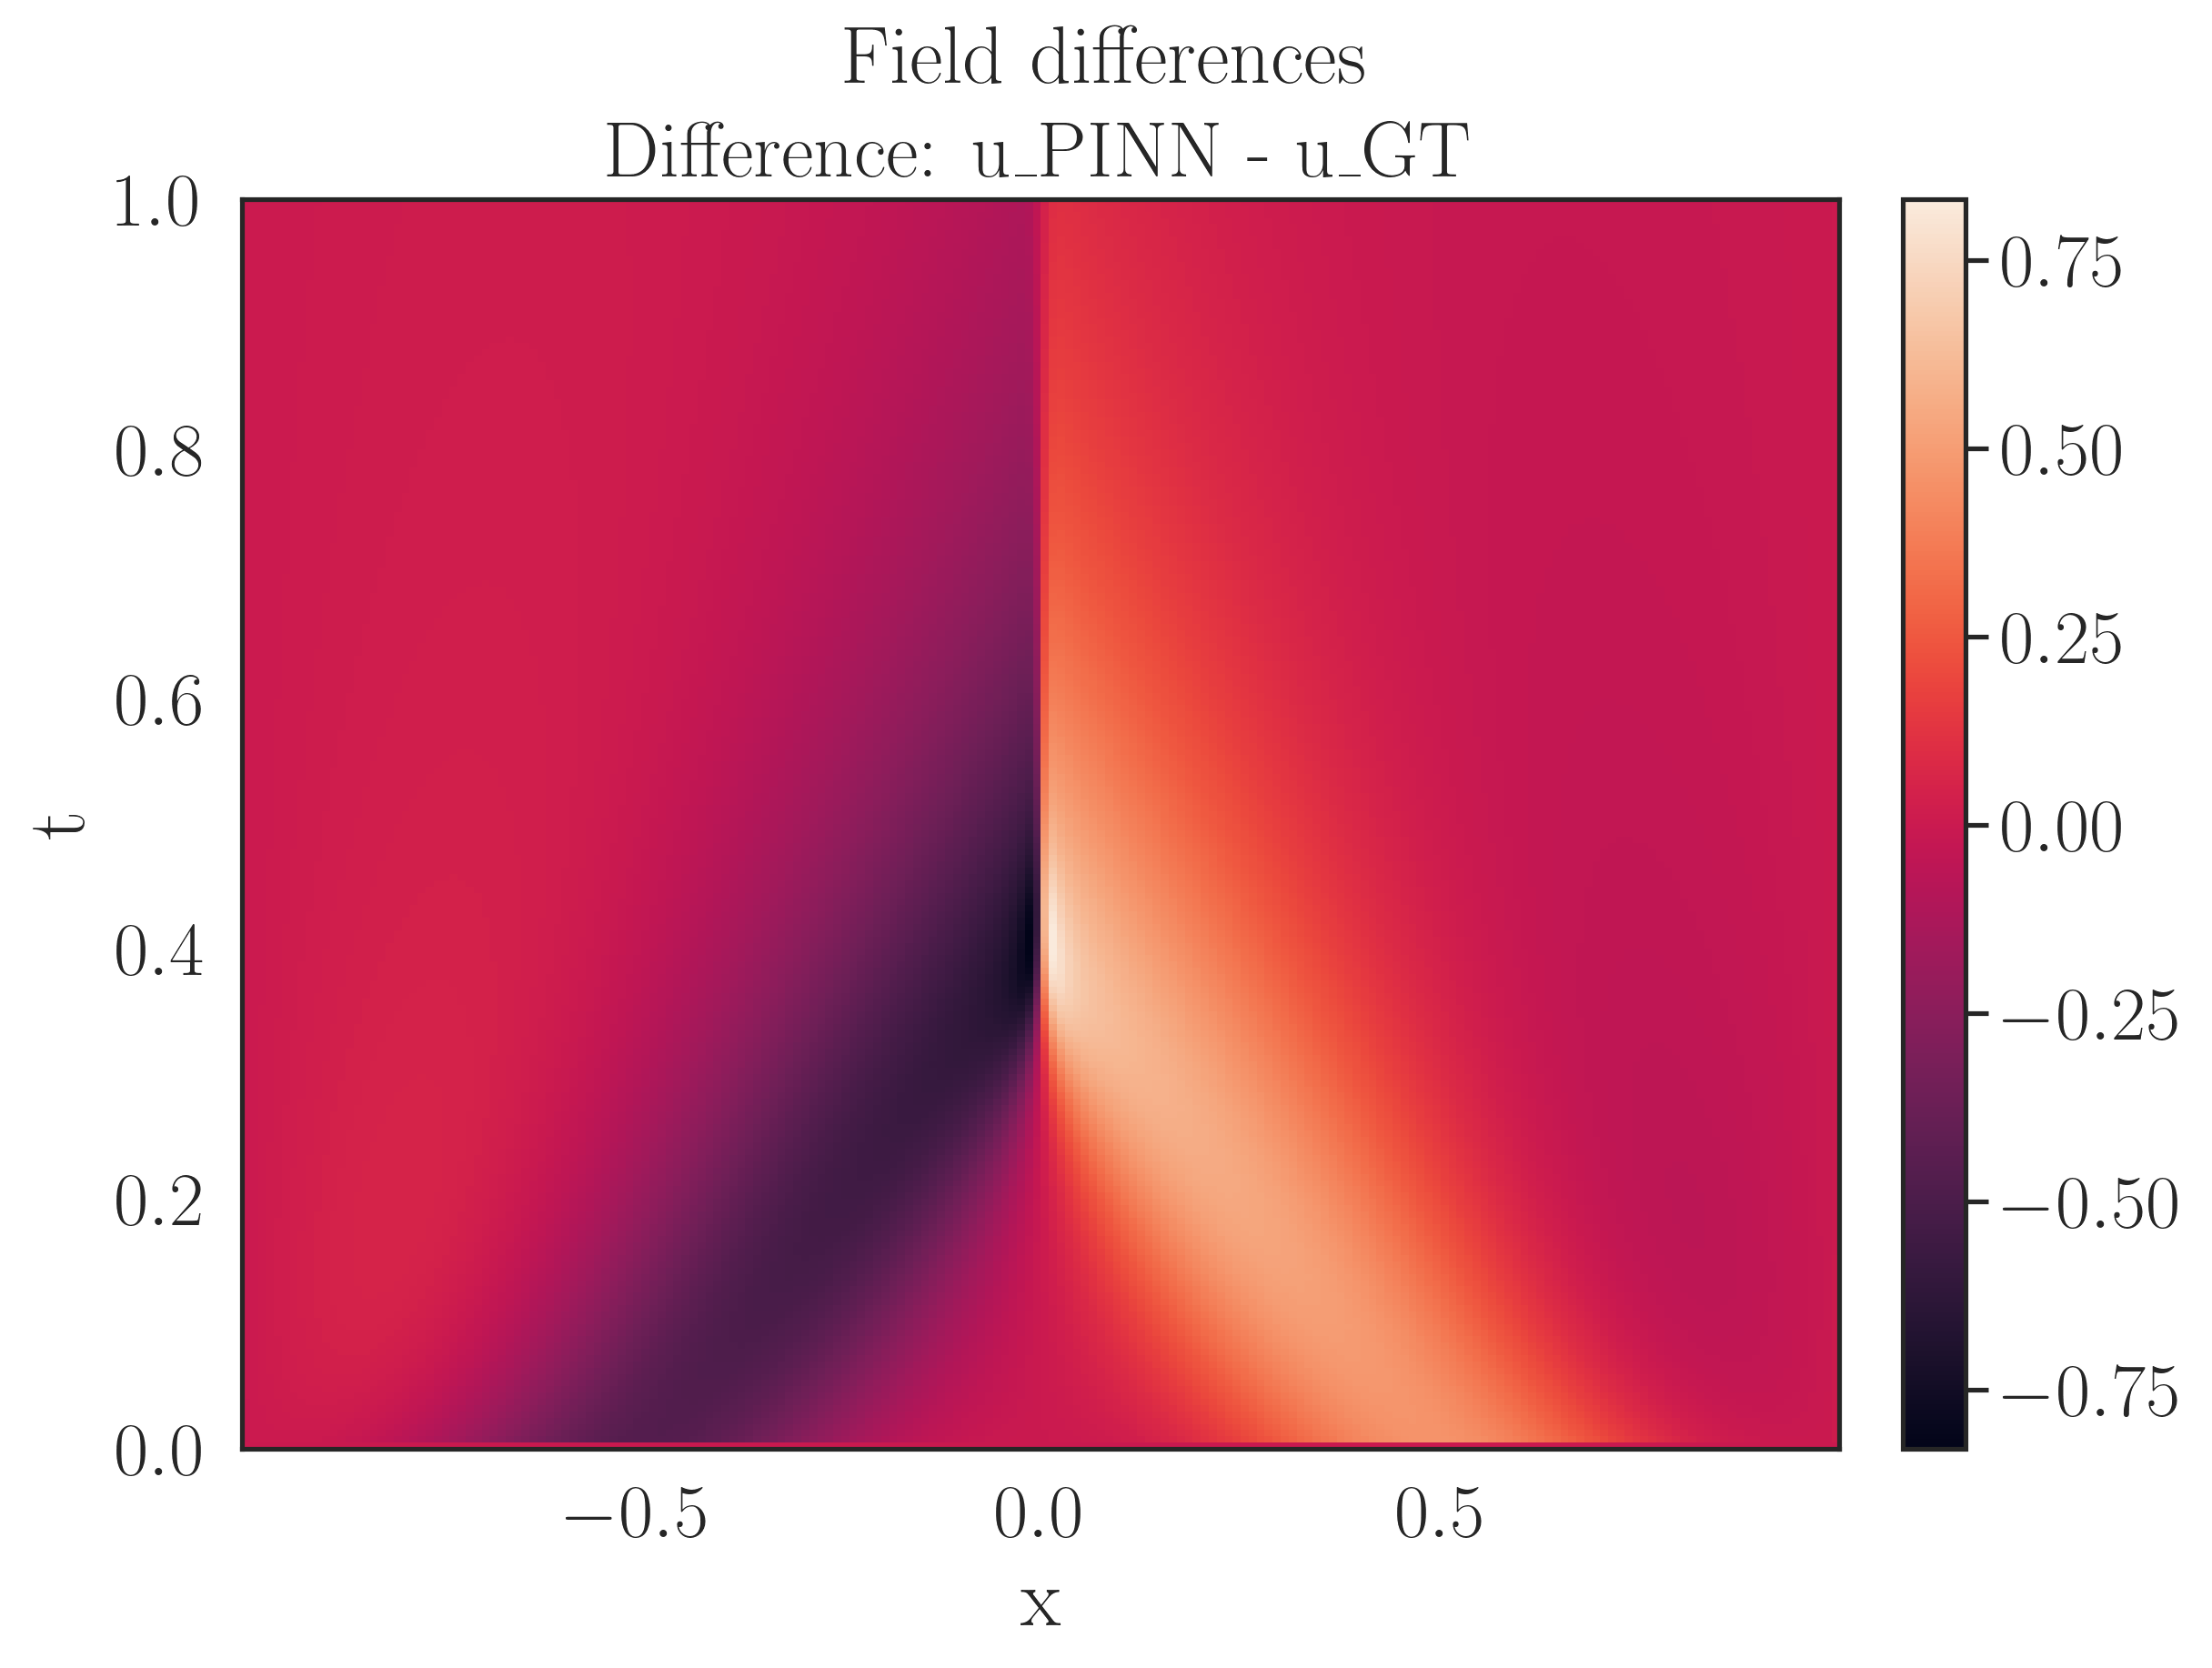

[saved] /home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/results/SA-PINN-ACTO_PINN_vs_GT.pdf
[saved] /home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/results/SA-PINN-ACTO_Field_differences.pdf


In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt


folder = '/home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/results'
#pinn_path = '/home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/pinn_runs/Vanilla_PINN_periodic_run_dump_20260429-022707.npz'
#pinn_path = '/home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/pinn_runs/SA_PINN_periodic_run_dump_20260429-033934.npz'
pinn_path = '/home/thiagos/Benchmark_PINNS/SA-PINN-ACTO/pinn_runs/SA_ACTO_PINN_periodic_run_dump_20260429-034906.npz'
nu = 0.01 / np.pi
L = 1.0

pinn = np.load(pinn_path, allow_pickle=True)
#gt   = np.load(gt_path,   allow_pickle=True)

# Set up grids: we need to different grids?
t_eval_p = pinn["t_eval"].astype(np.float64)
x_eval_p = pinn["x_eval"].astype(np.float64)
#t_eval_gt = gt["t_eval"].astype(np.float64)
#x_eval_gt = gt["x_eval"].astype(np.float64)
#gt =  

# Load fields: system of equations dependent
u_pinn  = pinn["u_grid"].astype(np.float64)
#u_gt    = gt["u_grid"].astype(np.float64)
u_gt = cole_hopf_burgers_1d(x_eval_p, t_eval_p, nu, L, K=10)

#x_domain = 1.0 # system dependent, change it here! 
#L = float(gt.get("L", pinn.get("L", x_domain)))

# If grids differ, remap GT → PINN grid. Do we need another function for the Dirichlet initial conditions, or Neumann?
def periodic_interp_space_vec(x_src, Ytx, x_q, L):
    x_ext = np.concatenate([x_src - 2*L, x_src, x_src + 2*L])
    out = np.empty((Ytx.shape[0], x_q.size), dtype=np.float64)
    xq = ((x_q + L) % (2*L)) - L
    for it in range(Ytx.shape[0]):
        y_ext = np.concatenate([Ytx[it], Ytx[it], Ytx[it]])
        out[it] = np.interp(xq, x_ext, y_ext)
    return out

def interp_time_vec(t_src, Ytx, t_q):
    Nt_q, Nx = t_q.size, Ytx.shape[1]
    out = np.empty((Nt_q, Nx), dtype=np.float64)
    for j in range(Nx):
        out[:, j] = np.interp(t_q, t_src, Ytx[:, j])
    return out

def remap_to_grid(t_src, x_src, Ytx, t_dst, x_dst, L):
    Y_t = interp_time_vec(t_src, Ytx, t_dst)
    Y_x = periodic_interp_space_vec(x_src, Y_t, x_dst, L)
    return Y_x

#if (not np.allclose(t_eval_k, t_eval_p)) or (not np.allclose(x_eval_k, x_eval_p)):
#    u_gt_on_p  = remap_to_grid(t_eval_k, x_eval_k, n_kt,  t_eval_p, x_eval_p, L)
#else:
#    u_gt_on_p  = u_gt
u_gt_on_p  = u_gt

# Compute rlative L2 errors over spacetime (weighted by dt * dx)
dx = (x_eval_p[-1] - x_eval_p[0]) / (x_eval_p.size - 1)
dt = (t_eval_p[-1] - t_eval_p[0]) / (t_eval_p.size - 1)

def rel_l2(phi_pinn, phi_gt, dx, dt):
    num = np.sqrt(np.sum((phi_pinn - phi_gt)**2) * dx * dt)
    den = np.sqrt(np.sum((phi_gt)**2) * dx * dt)
    return 0.0 if den == 0.0 else num / den

Erel_u  = rel_l2(u_pinn,  u_gt_on_p,  dx, dt)
#Erel_J0 = rel_l2(J0_pinn, J0_kt_on_p, dx, dt) # add here if the solution is larger than 1 output!

print(f"Relative L2(u)  over spacetime = {Erel_u:.6e}")
#print(f"Relative L2(J0) over spacetime = {Erel_J0:.6e}") # add here if the solution is larger than 1 output!

# Save text report
report_path = os.path.join(folder, "L2_results.txt")
with open(report_path, "w") as f:
    f.write(f"Relative L2(u)  over spacetime = {Erel_u:.6e}\n")
#    f.write(f"Relative L2(J0) over spacetime = {Erel_J0:.6e}\n") # add here if the solution is larger than 1 output!
print(f"[saved] {report_path}")

# Simple helpers for visualization
def heat(ax, Z, title, t_axis, x_axis):
    im = ax.imshow(
        Z, origin="lower",
        extent=[x_axis[0], x_axis[-1], t_axis[0], t_axis[-1]],
        aspect="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


PINN_name = 'SA-PINN-ACTO'
# Plots
fig1, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
heat(axs[0], u_pinn,    f"{PINN_name} PINN: u(t,x)", t_eval_p, x_eval_p)
heat(axs[1], u_gt_on_p, "GT: u(t,x)",                t_eval_p, x_eval_p)
plt.suptitle("PINN vs GT fields")
fig1_path = os.path.join(folder, f"{PINN_name}_PINN_vs_GT.pdf") # save as a pdf file!
plt.savefig(fig1_path, dpi=300)
plt.show()

#fig1, axs = plt.subplots(1, 2, figsize=(12, 8), constrained_layout=True)
#heat(axs[0,0], u_pinn,        f"{PINN_name} PINN: u(t,x)",  t_eval_p, x_eval_p)
#heat(axs[0,1], u_gt_on_p,     "GT:   u(t,x)",  t_eval_p, x_eval_p)
#heat(axs[1,0], J0_pinn,       "PINN: J0(t,x)", t_eval_p, x_eval_p) # add here if the solution is larger than 1 output! 
#heat(axs[1,1], J0_kt_on_p,    "KT:   J0(t,x)", t_eval_p, x_eval_p)

#fig2, axs = plt.subplots(1, 1, figsize=(12, 4), constrained_layout=True)
#heat(axs[0], u_pinn - u_gt_on_p,  "Difference: u_PINN - u_GT",  t_eval_p, x_eval_p)
#heat(axs[1], J0_pinn - J0_kt_on_p, "Difference: J0_PINN - J0_KT", t_eval_p, x_eval_p) # add here if the solution is larger than 1 output!
fig2, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
heat(ax, u_pinn - u_gt_on_p, "Difference: u_PINN - u_GT", t_eval_p, x_eval_p)
plt.suptitle("Field differences")
fig2_path = os.path.join(folder, f"{PINN_name}_Field_differences.pdf") # save as a pdf file!
plt.savefig(fig2_path, dpi=300)
plt.show()

print(f"[saved] {fig1_path}")
print(f"[saved] {fig2_path}")    


Vanilla


### Plot suggestions

In [ ]:
### Plot_1: Global L^2 vs. epoch/wall-time, simulation time

#L2_history
#wall_times
#epochs

hist = np.load(os.path.join(folder, "training_history.npz")) # change here to a right filename!

# Load history data
L2_hist = hist["L2"]
wall_time = hist["wall_time"]
epochs = hist["epochs"]

### Plot_1.1: Global L^2 vs. epoch
plt.figure()
plt.plot(epochs, L2_hist)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("L2 error")
plt.title("L2 vs Epoch")
#plt.savefig(os.path.join(folder, "L2_vs_epoch.pdf"), dpi=300)
plt.show()

### Plot_1.2: Global L^2 vs. wall time
plt.figure()
plt.plot(wall_time, L2_hist)
plt.yscale("log")
plt.xlabel("Wall time [s]")
plt.ylabel("L2 error")
plt.title("L2 vs Wall Time")
plt.savefig(os.path.join(folder, "L2_vs_time.pdf"), dpi=300)
plt.show()

### Plot_1.3: Global L^2 vs. simulation time
L2_t = np.sqrt(np.mean((u_pinn - u_gt_on_p)**2, axis=1))
L2_t /= np.sqrt(np.mean(u_gt_on_p[0]**2))

plt.plot(t_eval_p, L2_t)
plt.yscale("log")
plt.xlabel("Simulation time")
plt.ylabel("L2(t)")
plt.title("Error vs Physical Time")
plt.show()

### Plot_2: L2(x,t) Heatmap

L2_grid = (u_pinn - u_gt_on_p)**2
L2_plot = np.maximum(L2_grid, 1e-16)

fig, ax = plt.subplots(figsize=(6,5))

### Plot

im = ax.imshow(
    L2_plot,
    origin="lower",
    extent=[x_eval_p[0], x_eval_p[-1], t_eval_p[0], t_eval_p[-1]],
    aspect="auto",
    norm=plt.matplotlib.colors.LogNorm()
)

ax.set_title("L2 Error Heatmap")
ax.set_xlabel("x")
ax.set_ylabel("t")

plt.colorbar(im, ax=ax)
#plt.savefig(os.path.join(folder, "L2_heatmap.pdf"), dpi=300)
plt.show()

### EXECUTION TIME (Adam + LBFGS)
times = np.load(os.path.join(folder, "timing.npz")) # change here to the right filename and/or path

adam_time = times["adam_time"]
lbfgs_time = times["lbfgs_time"]
total_time = times["total_time"]

# print them! 
print(f"""
Execution time:
Adam   : {adam_time:.2f} s
LBFGS  : {lbfgs_time:.2f} s
Total  : {total_time:.2f} s
""")


In [ ]:

# ========================
# Plots
# ========================

# ================= Plot 1: PINN vs true solution at a few times
#fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
#ts = [0, 20, 100, 199]
#cmap = plt.cm.viridis
#colors = cmap(np.linspace(0, 1, len(ts)))
#for i, t_idx in enumerate(ts):
#    label = f"t={t_eval[t_idx]:.2f}"
#    axes[0].plot(x_eval, u_true[t_idx, :], c=colors[i], ls="--", lw=2, label=label)
#    axes[1].plot(x_eval, u_grid[t_idx, :], c=colors[i], lw=2, label=label)
#axes[0].set_title("Ground truth (Cole–Hopf)")
#axes[1].set_title("PINN solution")
#for ax in axes:
#    ax.grid(True, alpha=0.2)
#    ax.set_ylabel("u")
#axes[1].set_xlabel("x")
#axes[0].legend(loc="upper right", frameon=False, ncol=2)
#fig.suptitle(f"Relative L2 error = {L2_relative:.2e}", fontsize=12)
#plt.tight_layout()
#plt.savefig("u_vs_true.pdf", bbox_inches="tight", dpi=200)
#plt.close(fig)

# ================= Plot 2: Spacetime plot of PINN solution
#fig, ax = plt.subplots(figsize=(9, 5))
#pc = ax.pcolormesh(x_eval, t_eval, u_grid, shading="auto", cmap="RdGy")
#plt.colorbar(pc, ax=ax, label="u")
#ax.set_title("PINN solution u(t, x)")
#ax.set_xlabel("x")
#ax.set_ylabel("t")
#plt.tight_layout()
#plt.savefig("u_pinn_heatmap.pdf", bbox_inches="tight", dpi=200)
#plt.close(fig)

# ================= Plot 3: Residual heatmap
#fig, ax = plt.subplots(figsize=(9, 5))
#pc = ax.pcolormesh(x_eval, t_eval, np.abs(r_pde_grid), shading="auto", cmap="viridis", norm="log")
#plt.colorbar(pc, ax=ax, label="|PDE residual|")
#ax.set_title("PDE residual |R(t, x)|")
#ax.set_xlabel("x")
#ax.set_ylabel("t")
#plt.tight_layout()
#plt.savefig("pde_residual_heatmap.pdf", bbox_inches="tight", dpi=200)
#plt.close(fig)

# ================= Plot 4: Pointwise error heatmap
#fig, ax = plt.subplots(figsize=(9, 5))
#pc = ax.pcolormesh(x_eval, t_eval, np.log10(L2_pointwise_plot), shading="auto", cmap="inferno")
#plt.colorbar(pc, ax=ax, label="log10(sq. error)")
#ax.set_title("Pointwise squared error (log scale)")
#ax.set_xlabel("x")
#ax.set_ylabel("t")
#plt.tight_layout()
#plt.savefig("error_heatmap.pdf", bbox_inches="tight", dpi=200)
#plt.close(fig)

# ================= Plot 5: Adam loss history (if long enough)
#if len(adam_loss_history) > 10:
#    fig, ax = plt.subplots(figsize=(9, 4.5))
#    ax.plot(adam_loss_history, color="tab:blue", lw=1.2, alpha=0.9)
#    ax.set_yscale("log")
#    ax.set_xlabel("Adam epoch")
#    ax.set_ylabel("loss")
#    ax.set_title("Adam training loss")
#    ax.grid(True, alpha=0.25)
#    plt.tight_layout()
#    plt.savefig("adam_loss.pdf", bbox_inches="tight", dpi=200)
#    plt.close(fig)

#print("Done. Plots saved to current directory.")

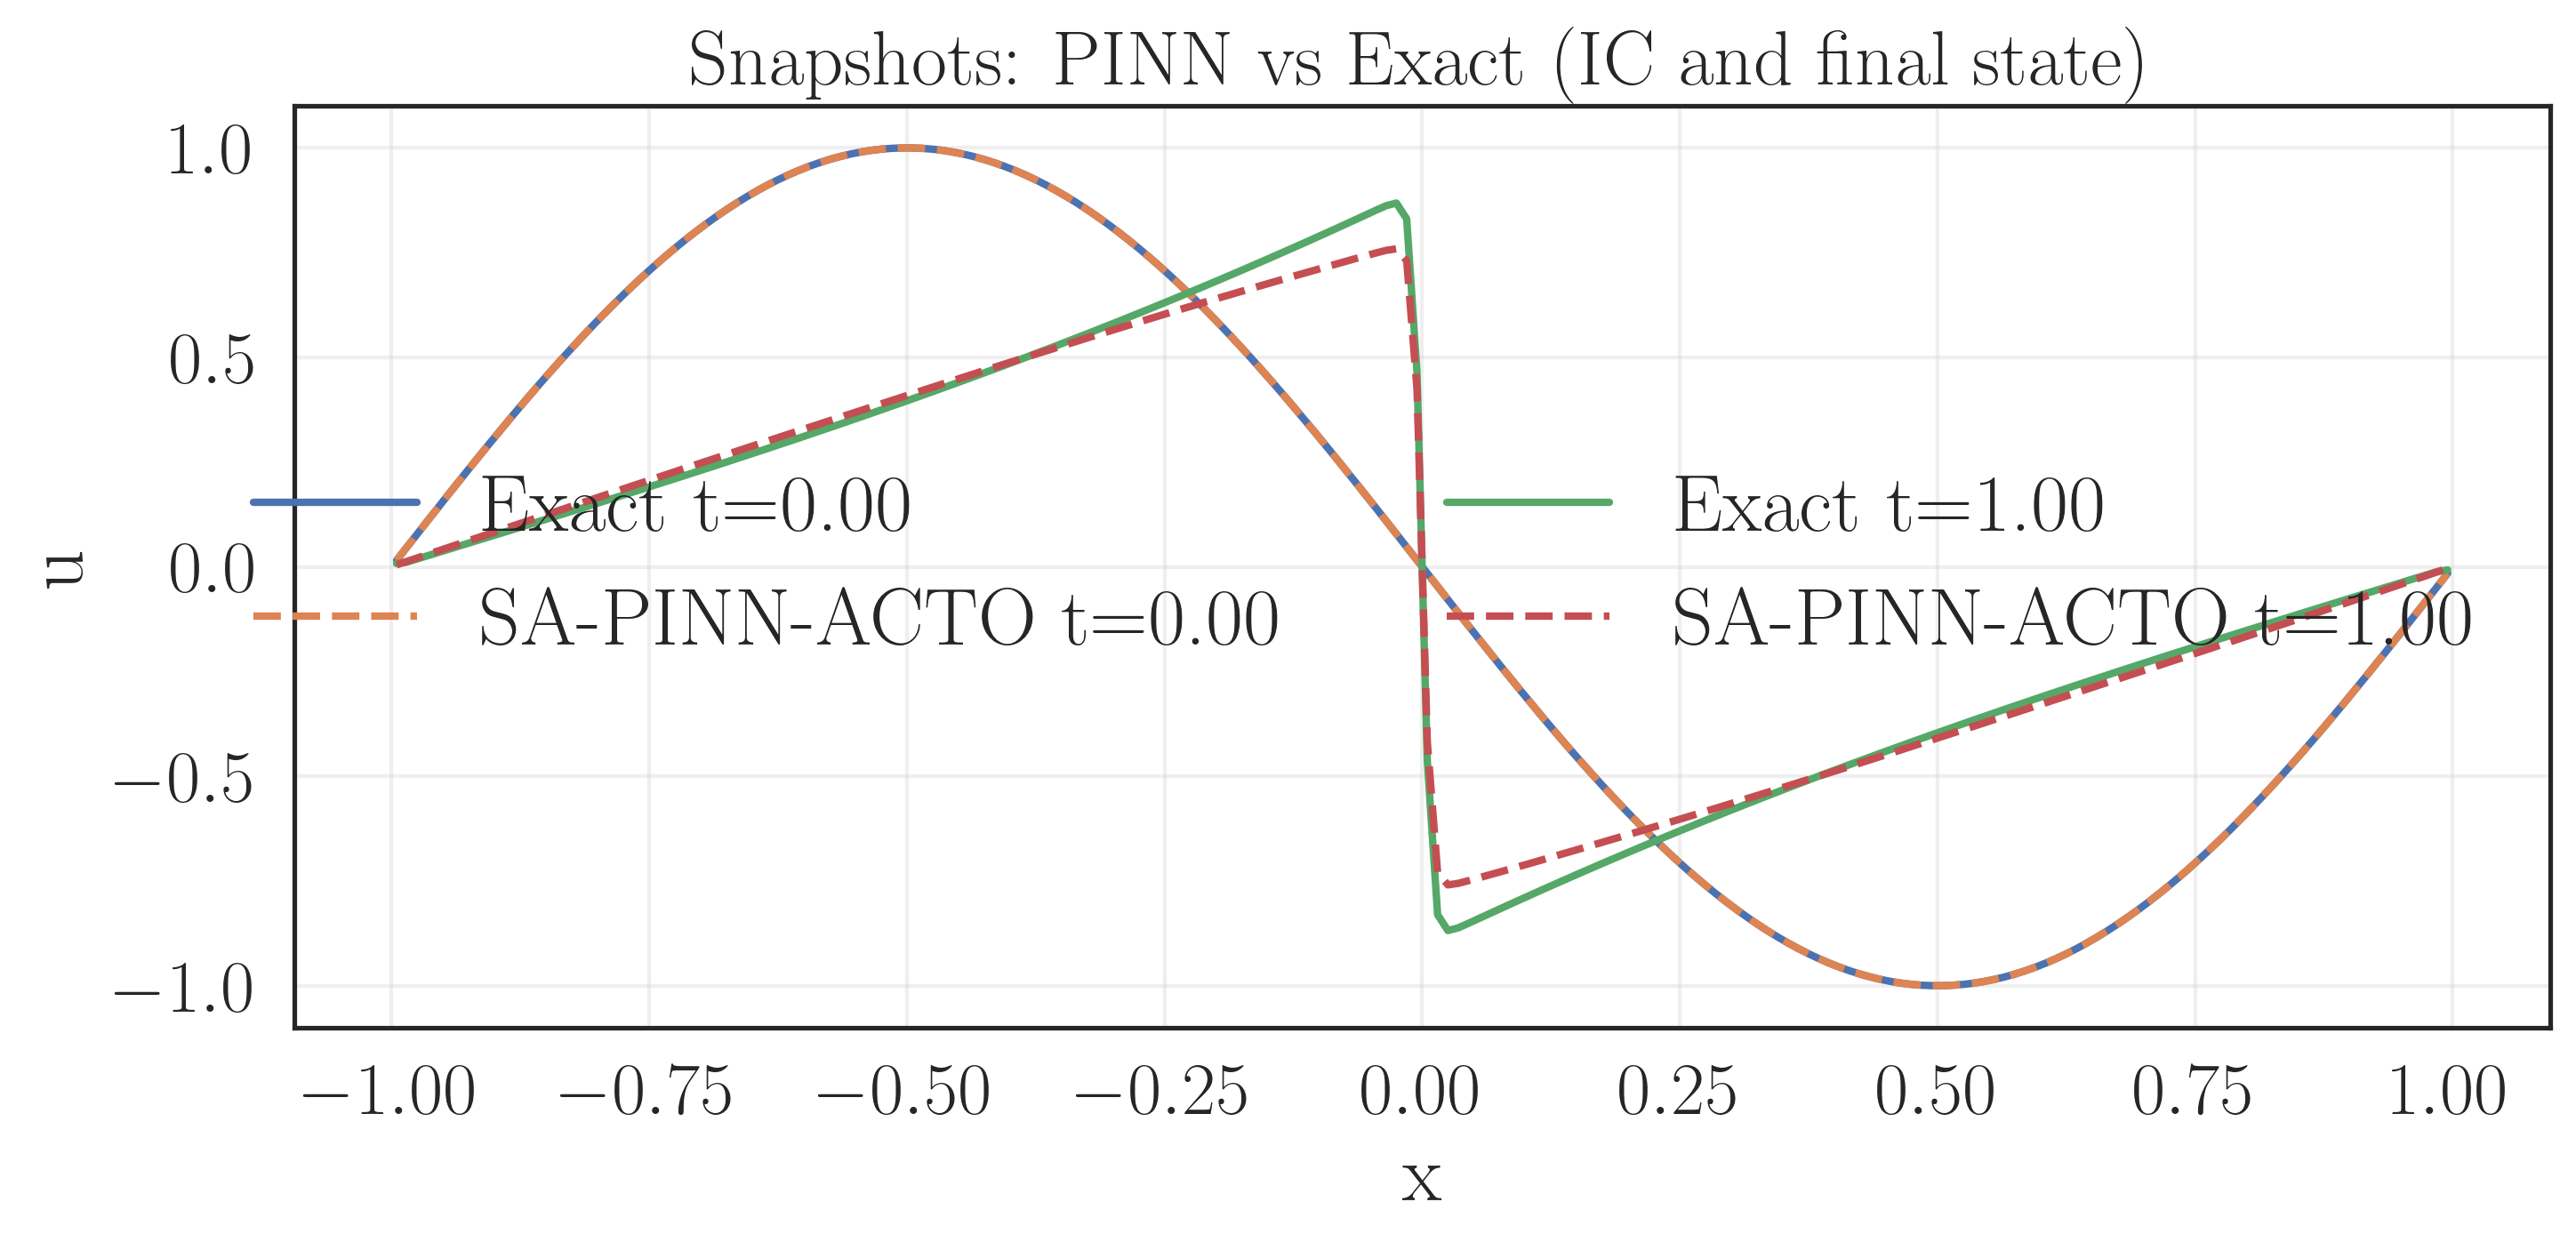

In [41]:
def snapshots_overlay(x, t, u_pinn, u_gt, save_path=None, name="PINN"):

    fig, ax = plt.subplots(figsize=(10, 5))

    # Indices: initial and final
    idxs = [0, -1]

    for idx in idxs:
        ti = t[idx]

        # Ground truth (solid)
        ax.plot(
            x, u_gt[idx, :],
            linestyle="-",
            linewidth=2,
            label=f"Exact t={ti:.2f}"
        )

        # PINN (dashed)
        ax.plot(
            x, u_pinn[idx, :],
            linestyle="--",
            linewidth=2,
            label=f"{name} t={ti:.2f}"
        )

    ax.set_xlabel("x")
    ax.set_ylabel("u")
    ax.set_title("Snapshots: PINN vs Exact (IC and final state)")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, ncol=2)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

snapshots_overlay(
    x_eval_p,
    t_eval_p,
    u_pinn,
    u_gt_on_p,
    save_path=os.path.join(folder, f"{PINN_name}_snapshots_overlay.pdf"),
    name=PINN_name
)    